1. Познакомьтесь с данными.
2. Осуществите предобработку данных.
    - 2.1 Приведите заголовки к удобному виду.
    - 2.2 Проверьте типы данных.
    - 2.3 Обработайте пропуски.
    - 2.4 Проверьте наличие дубликатов.
    - 2.5 Исключите нулевые значения в выручке для дальнейшего исследования. 
3. Исследовательский анализ данных:
     - 3.1 Создайте отчет о динамике продаж (выручке). Постройте линейный график. Повторите отчет с детализацией по полям: FFP_FLAG, ROUTE_FLIGHT_TYPE, SALE_TYPE. (Тут динамика) Постройте общие отчеты по выручке по типам пассажиров, по типам перелета, по способам покупки, по программам лояльности. Визуализируйте каждый отчет. Решение о детализации отчетов примите самостоятельно.
     - 3.2 Исследуйте выручку, примите решение об исключении выбросов для дальнейшего исследования, руководствуясь минимизацией потерь в данных.
     - 3.3 Исследуйте сезонность продаж. Дополнительно проверьте гипотезу о том, что выручка от продаж осенью и зимой отличается. Исследуйте выручку и число продаж по месяцам, проверьте корреляцию.
     - 3.4 Клиенты покупают билеты в разное время. Кто-то покупает билеты заранее, другие - в последний момент. Проверьте гипотезу о том, что выручка от продажи билетов для этих двух групп клиентов отличается. Предварительно разбейте клиентов минимум на три группы.
     - 3 .5  Определите топ-10 популярных направлений перелета (город-город) отдельно для ВМЛ и МВЛ. Изучите выручку для этих направлений. Для этого добавьте в датасет сведения о городах, используя данные из датасета:
     https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat
     - 3.6 Определите есть ли зависимость выручки от других признаков. Постройте матрицу корреляций.

Каждый пункт исследования сопроводите выводами.


In [1]:
# импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import t, norm
from scipy import stats as st

In [2]:
df = pd.read_csv('air_data.csv', sep=';')
df

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE
0,2021-12-07 00:00:00,2022-01-11 00:00:00,AD,200,MOW,KGD,ВВЛ,NaN,ONLINE
1,2021-12-31 00:00:00,2022-01-03 00:00:00,AD,610,UUS,OVB,ВВЛ,NaN,OFFLINE
2,2021-11-28 00:00:00,2022-01-04 00:00:00,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE
3,2021-12-08 00:00:00,2022-01-05 00:00:00,AD,190,VOZ,MOW,ВВЛ,NaN,ONLINE
4,2021-12-08 00:00:00,2022-01-12 00:00:00,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE
...,...,...,...,...,...,...,...,...,...
49995,2022-06-11 00:00:00,2022-06-22 00:00:00,CHD,480,MOW,OMS,ВВЛ,NaN,ONLINE
49996,2022-06-06 00:00:00,2022-06-20 00:00:00,AD,270,LED,MOW,ВВЛ,NaN,OFFLINE
49997,2022-06-26 00:00:00,2022-06-29 00:00:00,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE
49998,2022-06-26 00:00:00,2022-06-28 00:00:00,AD,270,KZN,MOW,ВВЛ,NaN,OFFLINE


In [3]:
df.columns = ['дата покупки', 'дата совершения перелета', 'тип пассажиров', 'сумма', 'город отправления', 'город назначения', 'тип перелета', 'наличие программы лояльности', 'способ покупки']

In [4]:
df.head(1)

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки
0,2021-12-07 00:00:00,2022-01-11 00:00:00,AD,200,MOW,KGD,ВВЛ,NaN,ONLINE


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   дата покупки                  50000 non-null  object
 1   дата совершения перелета      50000 non-null  object
 2   тип пассажиров                50000 non-null  object
 3   сумма                         50000 non-null  int64 
 4   город отправления             49998 non-null  object
 5   город назначения              49999 non-null  object
 6   тип перелета                  50000 non-null  object
 7   наличие программы лояльности  19398 non-null  object
 8   способ покупки                50000 non-null  object
dtypes: int64(1), object(8)
memory usage: 3.4+ MB


In [6]:
df.duplicated().sum()

np.int64(169)

In [7]:
df = df.drop_duplicates()

In [8]:
df[df['город отправления'].isna()]

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки
2020,2022-02-17 00:00:00,2022-03-22 00:00:00,AD,440,NaN,KHV,МВЛ,NaN,ONLINE
8100,2022-05-02 00:00:00,2022-05-11 00:00:00,AD,440,NaN,KHV,МВЛ,NaN,OFFLINE


In [9]:
df['город отправления'] = df['город отправления'].fillna('неизвестно')

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\2263772650.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['город отправления'] = df['город отправления'].fillna('неизвестно')


In [10]:
df[df['город назначения'].isna()]

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки
47582,2022-05-13 00:00:00,2022-07-28 00:00:00,AD,440,KHV,NaN,МВЛ,NaN,OFFLINE


In [11]:
df['город назначения'] = df['город назначения'].fillna('неизвестно')

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\390330154.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['город назначения'] = df['город назначения'].fillna('неизвестно')


In [12]:
df['наличие программы лояльности'].unique()

array([nan, 'FFP'], dtype=object)

In [13]:
df['наличие программы лояльности'] = df['наличие программы лояльности'].fillna('нет')

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\357305638.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['наличие программы лояльности'] = df['наличие программы лояльности'].fillna('нет')


In [14]:
df['наличие программы лояльности'] = df['наличие программы лояльности'].replace('FFP', 'есть')

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\2737492371.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['наличие программы лояльности'] = df['наличие программы лояльности'].replace('FFP', 'есть')


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['тип пассажиров'].unique()

array(['AD', 'CHD', 'INF'], dtype=object)

In [17]:
df['дата покупки'] = pd.to_datetime(df['дата покупки'])

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1289616478.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['дата покупки'] = pd.to_datetime(df['дата покупки'])


In [18]:
df['дата совершения перелета'] = pd.to_datetime(df['дата совершения перелета'])

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\503544230.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['дата совершения перелета'] = pd.to_datetime(df['дата совершения перелета'])


In [19]:
df['год'] = df['дата покупки'].dt.year 
df['название месяца'] = df['дата покупки'].dt.month_name()
df['месяц'] = df['дата покупки'].dt.month
df['день недели'] = df['дата покупки'].dt.dayofweek
df['квартал'] = df['дата покупки'].dt.quarter
df.head()

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1039806694.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['год'] = df['дата покупки'].dt.year
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1039806694.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['название месяца'] = df['дата покупки'].dt.month_name()
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1039806694.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,нет,ONLINE,2021,December,12,1,4
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,нет,OFFLINE,2021,December,12,4,4
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,есть,ONLINE,2021,November,11,6,4
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,нет,ONLINE,2021,December,12,2,4
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,есть,OFFLINE,2021,December,12,2,4


Создадим временные столбцы именно по дате покупки билета. В будущем это нам понадобится для анализа сезонности.

Далее надо понять, что делать с выручкой, равной нулю в некоторых строчках датасета. Совсем неочевидно сейчас, что просто удалить эти строки будет верным шагом. Возможно, их придется заполнить средним значением.

In [20]:
df[df['сумма'] == 0]['тип пассажиров'].value_counts()

тип пассажиров
INF    404
AD      60
CHD      2
Name: count, dtype: int64

In [21]:
df['тип перелета'].value_counts()

тип перелета
ВВЛ    45926
МВЛ     3905
Name: count, dtype: int64

Видим, что огромный процент перелётов составляют внутренние рейсы. Исходя из этого, а также из самого первого просмотра данных датасета, где мы видим несколько кодов городов (LED, MOW, KDG, KZN), можем смело сказать, что мы рассматриваем российскую авиакомпанию. Конечно, скорее всего это было и так очевидно, но почему-бы в этом не удостовериться?

Теперь по поводу выручки:
Изначально я думал, что в случаях, когда она была равна 0, означало, что люди покупали эти билеты, например, за мили. Но если посмотреть на value counts, видим, что большинство таких пассажиров имеют тип INF.
INF - это код младенцев (0-2 лет). Такие пассажиры летают по отдельным тарифам, стоимость которых намного меньше, чем у взрослых или детей. Исходя из этого, а также принимая во внимания, что в начале написано про скорректированную выручку, становятся понятным, откуда появляется нулевое значение. 
Следовательно, для дальнейшего исследования, мы можем смело удалить эти строки, чтобы они нам не мешали исследовать выручку более детально.
То, что в 60 случаях у взрослых она равна 0 - это видимо как раз связано с покупкой билета милями или чем-то похожим.

In [22]:
df = df.drop(df[df['сумма'] == 0].index).reset_index(drop=True)

In [23]:
df

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,нет,ONLINE,2021,December,12,1,4
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,нет,OFFLINE,2021,December,12,4,4
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,есть,ONLINE,2021,November,11,6,4
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,нет,ONLINE,2021,December,12,2,4
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,есть,OFFLINE,2021,December,12,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49360,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,нет,ONLINE,2022,June,6,5,2
49361,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,нет,OFFLINE,2022,June,6,0,2
49362,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,есть,ONLINE,2022,June,6,6,2
49363,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,нет,OFFLINE,2022,June,6,6,2


Переходим из предобработки к анализу 

3. Исследовательский анализ данных. 
3.1 Создайте отчет о динамике продаж (выручке). Постройте линейный график. Повторите отчет с детализацией по полям: FFP_FLAG (наличие программы лояльности), ROUTE_FLIGHT_TYPE(тип перелета), SALE_TYPE(способ покупки). Постройте общие отчеты по выручке по типам пассажиров, по типам перелета, по способам покупки, по программам лояльности. Визуализируйте каждый отчет. Решение о детализации отчетов примите самостоятельно.

In [24]:
table = df.groupby('дата совершения перелета')['сумма'].sum().reset_index()
table

,дата совершения перелета,сумма
0,2021-10-01,170
1,2021-10-02,7140
2,2021-10-03,7790
3,2021-10-04,7010
4,2021-10-05,16250
...,...,...
365,2022-10-01,83890
366,2022-10-02,85950
367,2022-10-03,61750
368,2022-10-04,55210


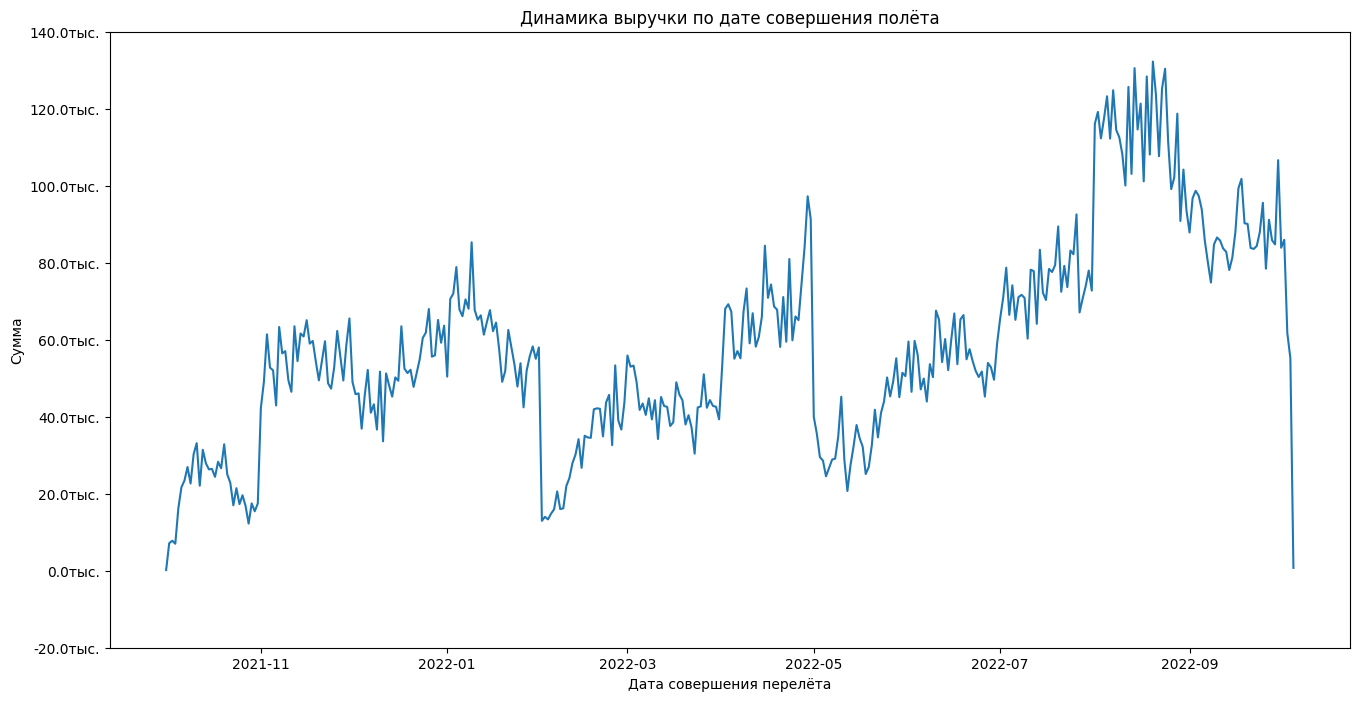

In [25]:
plt.figure(figsize=(16, 8))
sns.lineplot(table, x='дата совершения перелета', y='сумма')
plt.title('Динамика выручки по дате совершения полёта')
plt.ylabel('Сумма')
plt.xlabel('Дата совершения перелёта')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.show()
# current_ticks = plt.yticks()[0] - Данная строка возвращает массив числовых значений оси Y, 
# Если в индексе указать 1 вместо 0, вернётся массив текстовых значений

Сейчас, в понедельник, в последний день перед сдачей данной работы, я дописываю выводы и еще раз просматриваю полностью код. Только что я в следующих двух строчках построил график выручки по дате покупки билета, хотя изначально я исследовал динамику именно по дате совершения перелета (код сверху), и хочу заметить, наверное это было в данном случае верным решением. Просто изначально я решил, что так будет правильнее, поскольку каждый полёт - это по сути кумулятивная сумма от всех купленных билетов на этот рейс, которая как раз и отображается на графике выше. 
    
    
    График, который я построил снизу сейчас, выглядит по мне как-то странно. Например, по верхнему графику лучше видно, что у нас в августе была больше выручка, чем в остальных месяцах, просто потому что в этот период люди чаще летали (код с подтверждением этих слов есть ниже). 
    
    
    Конечно, понятно, что общая сумма выручки будет одинаковой. 

In [26]:
table = df.groupby('дата покупки')['сумма'].sum().reset_index()
table

,дата покупки,сумма
0,2021-10-01,60310
1,2021-10-02,33100
2,2021-10-03,34320
3,2021-10-04,58190
4,2021-10-05,60800
...,...,...
360,2022-09-26,39520
361,2022-09-27,48350
362,2022-09-28,44860
363,2022-09-29,27460


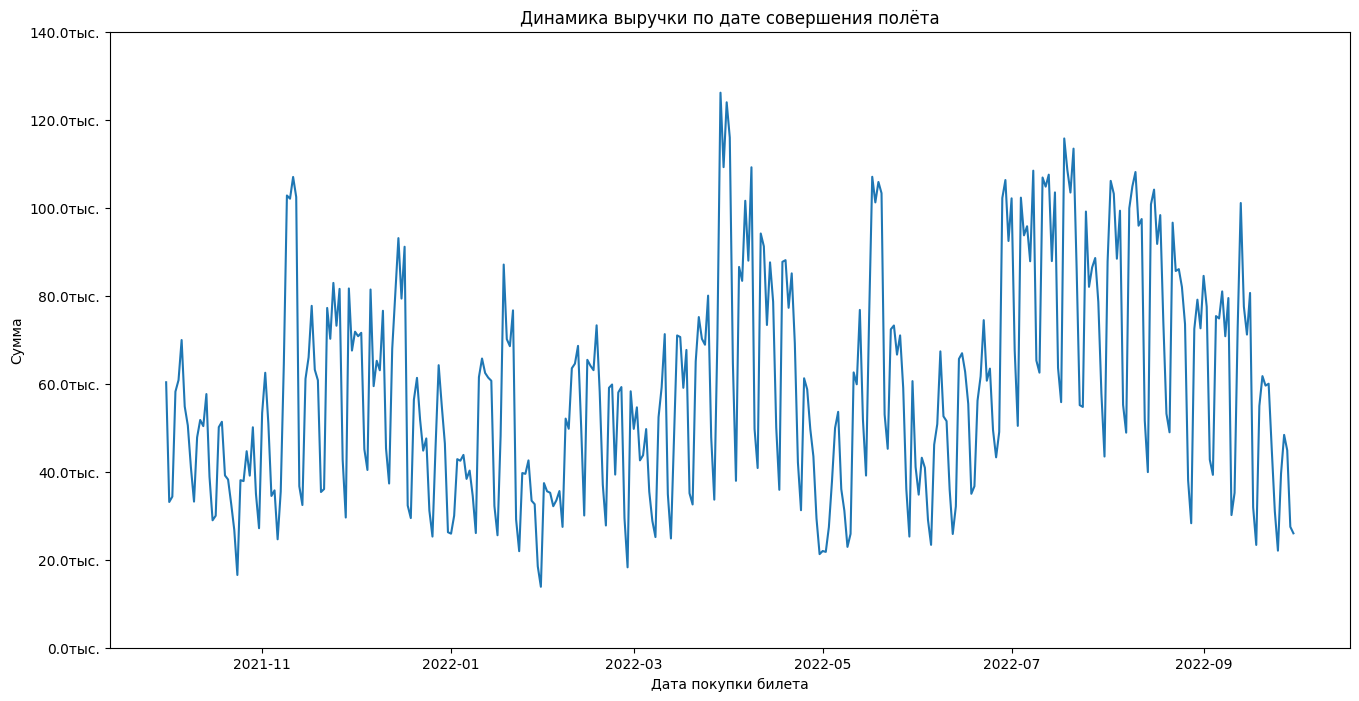

In [27]:
plt.figure(figsize=(16, 8))
sns.lineplot(table, x='дата покупки', y='сумма')
plt.title('Динамика выручки по дате совершения полёта')
plt.ylabel('Сумма')
plt.xlabel('Дата покупки билета')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.show()
# current_ticks = plt.yticks()[0] - Данная строка возвращает массив числовых значений оси Y, 
# Если в индексе указать 1 вместо 0, вернётся массив текстовых значений

Выводы по графику динамики выручки по дате совершения перелета:


Видим, что наибольшая выручка авиакомпании, почти достигающая значения в 140 тысяч, была в августе. Скорее всего, это связано с летним периодом отпусков, пик которого достигается в августе. Также компании в периоды такой высокой загруженности своих рейсов могут поднимать цены на авиабилеты, в связи с чем именно этот месяц и показывает наибольшие значения на графике.

Стоит отдельно заметить, что динамика рассматривается именно по датам совершения перелёта, а не по датам покупки билета, поскольку люди покупают билеты на один конкретный рейс в разное время: кто-то это делает заранее, за несколько месяцев; другие же могут сильно заранее, поэтому более корректным было бы рассматривать по дате непосредственно самого полёта.

In [28]:
df['сумма'].unique()

array([ 200,  610,  390,  190,  250,   70,  490,  280,  360,  380,  210,
        370, 1090,  470,  450,  300,  180,  570,  430,  350,  130,  230,
        290,  160,  420,  690,  340,  310,  520,  440,  400,  930,  240,
        170,  270,  150,  560,  260,  220,  680, 1820,  410,  630,  550,
        840,  110,  140,  100,  640,  720,  460,  120,  540,  330, 1030,
         40,  320,  530,  820,   50,  480,  960,  500,  760, 2000,  810,
        670,  790,  950,  590,  600,  510,  710,  830, 1140,  620,  750,
        770, 1200, 1110,  970, 1180,  740,  650,  730,  660,  800,  860,
        890,  920,  580,  700,  880,  850,  940, 1070,  910, 1690,  870,
       1930,  780, 2990, 1780,  980, 1620,   60,   90, 1150, 1160, 1040,
        900, 1760, 1320,   80, 1020, 2270,  990, 1260, 1080, 1940, 1060,
       1280, 1190, 1470, 1810, 1520, 1010, 1000, 1360, 1340, 1220, 1980,
       1530, 1330, 2300, 1450, 1630, 1510, 2060, 1590, 1120, 1500, 1860,
       1250, 1050, 1660, 1460, 1610, 2050, 1100, 15

In [29]:
df['название месяца'] = df['дата покупки'].dt.month_name()

In [30]:
df.head()

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,нет,ONLINE,2021,December,12,1,4
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,нет,OFFLINE,2021,December,12,4,4
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,есть,ONLINE,2021,November,11,6,4
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,нет,ONLINE,2021,December,12,2,4
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,есть,OFFLINE,2021,December,12,2,4


In [31]:
correct_month = ['November', 'December', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October']
table3 = df.groupby('название месяца')['сумма'].sum().reindex(correct_month).reset_index()
table3

,название месяца,сумма
0,November,1851260
1,December,1757250
2,January,1352390
3,February,1348210
4,March,1826430
5,April,2032570
6,May,1714240
7,June,1614500
8,July,2638430
9,August,2471260


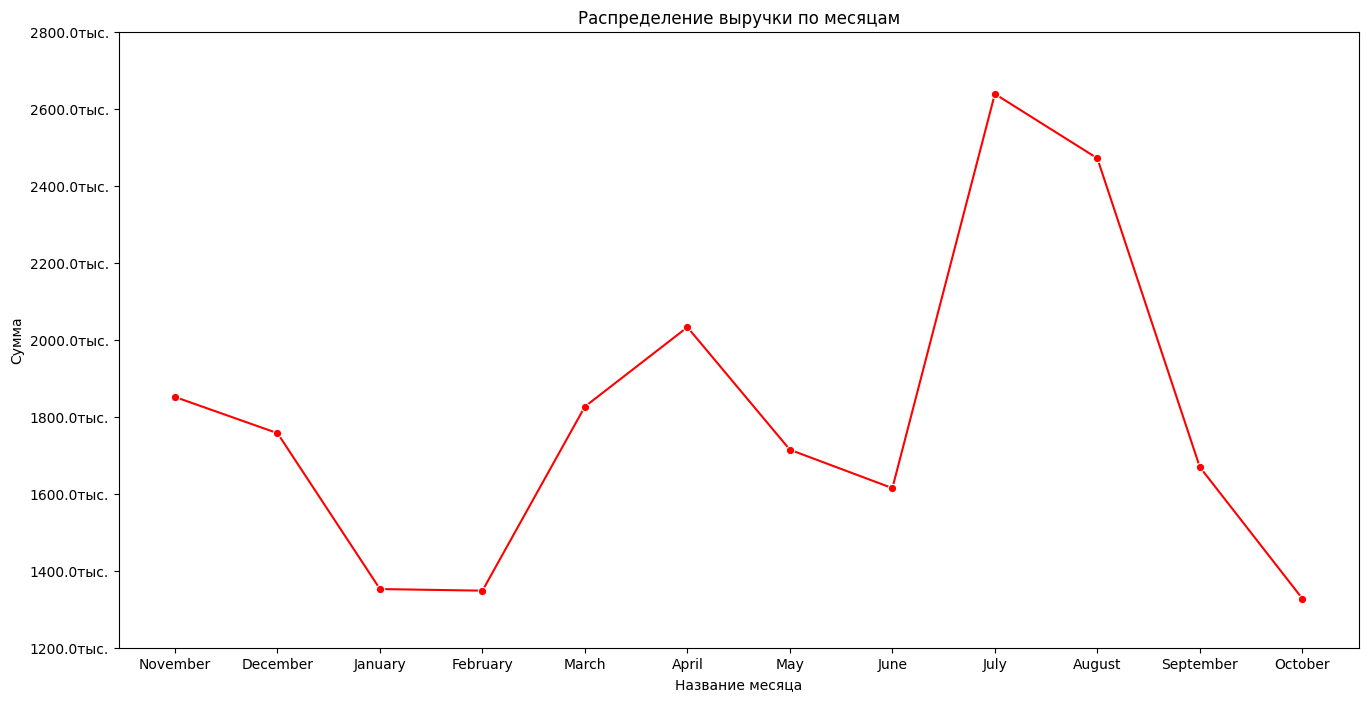

In [32]:
plt.figure(figsize=(16,8))
sns.lineplot(table3, x='название месяца', y='сумма', marker='o', color='red')
plt.title('Распределение выручки по месяцам')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.ylabel('Сумма')
plt.xlabel('Название месяца')
plt.show()


Хотя уже здесь, как мы можем заметить, максимальная точка по выручке была именно в июле, август при этом несильно отстаёт. Единственная причина, которая мне сейчас видится, заключается в том, что в июле просто больше людей по количеству куда-то летали. Исследуем эту ситуацию.

In [33]:
print(df[df['название месяца'] == 'July']['название месяца'].count())
print(df[df['название месяца'] == 'August']['название месяца'].count())

5259
4787


Похоже, это и правда так

In [34]:
july_sum = df[df['название месяца'] == 'July']['сумма'].sort_values(ascending=False).head(20).reset_index()
july_sum

,index,сумма
0,23968,2110
1,29046,2080
2,40915,2000
3,43759,1840
4,14062,1720
5,27273,1700
6,44823,1680
7,6968,1660
8,44874,1660
9,27197,1650


In [35]:
august_sum = df[df['название месяца'] == 'August']['сумма'].sort_values(ascending=False).head(20).reset_index()
august_sum

,index,сумма
0,10123,2950
1,22407,2510
2,25572,2470
3,45031,2170
4,17404,2170
5,15074,2040
6,10093,1820
7,38101,1790
8,12632,1790
9,42809,1770


In [36]:
july_sum['сумма'].sum()

np.int64(33010)

In [37]:
august_sum['сумма'].sum()

np.int64(37490)

Хотя при этом сумма топ-20 самых дорогих позиций у августа, но билетов в этом месяце было куплено меньше

Переходим к столбцу: "наличие программы лояльности"

In [38]:
table4 = df.groupby(['дата совершения перелета', 'наличие программы лояльности'])['сумма'].sum().reset_index()
table4

,дата совершения перелета,наличие программы лояльности,сумма
0,2021-10-01,есть,170
1,2021-10-02,есть,3050
2,2021-10-02,нет,4090
3,2021-10-03,есть,770
4,2021-10-03,нет,7020
...,...,...,...
733,2022-10-03,есть,18570
734,2022-10-03,нет,43180
735,2022-10-04,есть,2640
736,2022-10-04,нет,52570


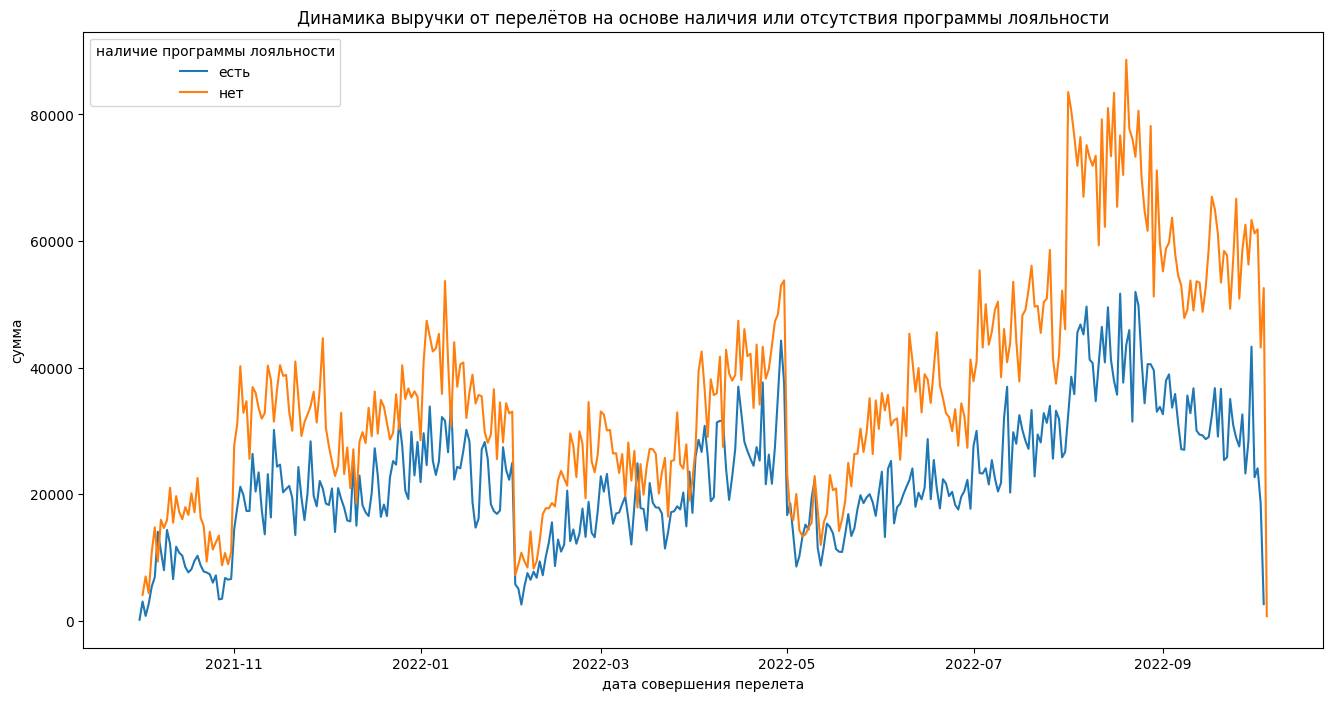

In [39]:
plt.figure(figsize=(16,8))
sns.lineplot(table4, x ='дата совершения перелета', y='сумма', hue='наличие программы лояльности')
plt.title('Динамика выручки от перелётов на основе наличия или отсутствия программы лояльности')
plt.show()

По значениям суммы слева от графика видим, что выручка больше от тех пассажиров, у которых нет программы лояльности. Впрочем, всё логично

In [40]:
table2 = df.groupby('наличие программы лояльности')['сумма'].sum().reset_index()
table2

,наличие программы лояльности,сумма
0,есть,8222390
1,нет,13381300


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1293741705.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(table2, x='наличие программы лояльности', y ='сумма', palette='Set1', estimator='sum')


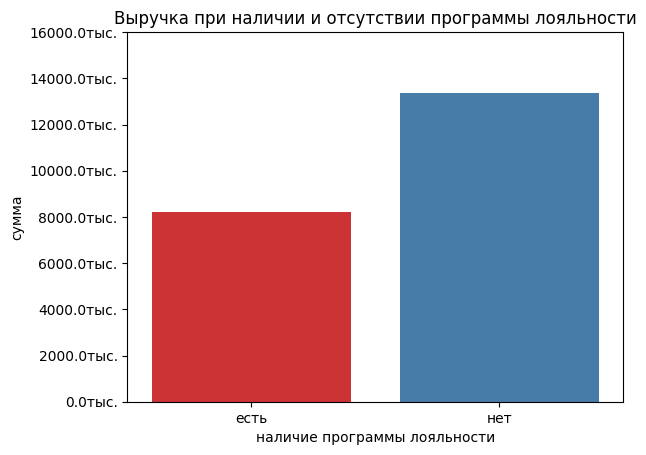

In [41]:
sns.barplot(table2, x='наличие программы лояльности', y ='сумма', palette='Set1', estimator='sum')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Выручка при наличии и отсутствии программы лояльности')
plt.show()

Далее про тип перелёта

In [42]:
table5 = df.groupby(['дата совершения перелета', 'тип перелета'])['сумма'].sum().reset_index()
table5

,дата совершения перелета,тип перелета,сумма
0,2021-10-01,ВВЛ,170
1,2021-10-02,ВВЛ,7140
2,2021-10-03,ВВЛ,5560
3,2021-10-03,МВЛ,2230
4,2021-10-04,ВВЛ,6200
...,...,...,...
723,2022-10-03,ВВЛ,57190
724,2022-10-03,МВЛ,4560
725,2022-10-04,ВВЛ,49820
726,2022-10-04,МВЛ,5390


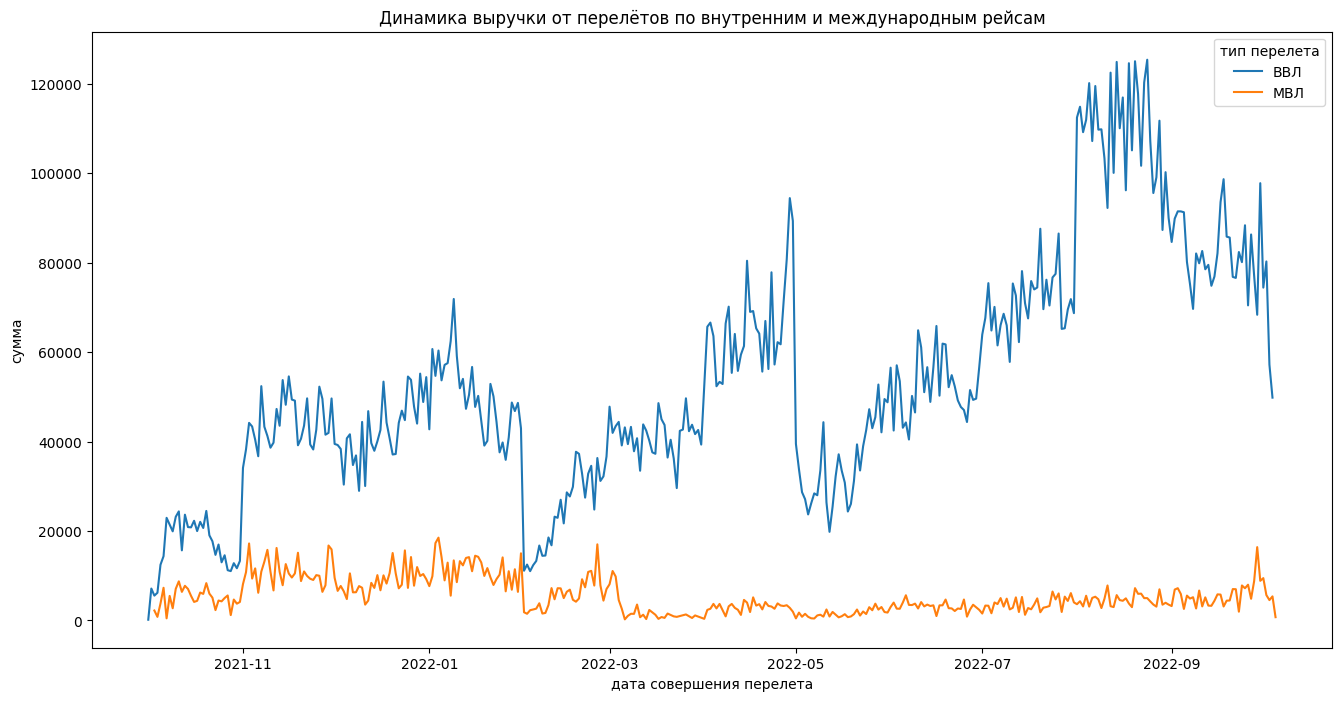

In [43]:
plt.figure(figsize=(16,8))
sns.lineplot(table5, x ='дата совершения перелета', y='сумма', hue='тип перелета')
plt.title('Динамика выручки от перелётов по внутренним и международным рейсам')
plt.show()

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\3174992199.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(table5, x='тип перелета', y ='сумма', palette='Set1', estimator='sum')


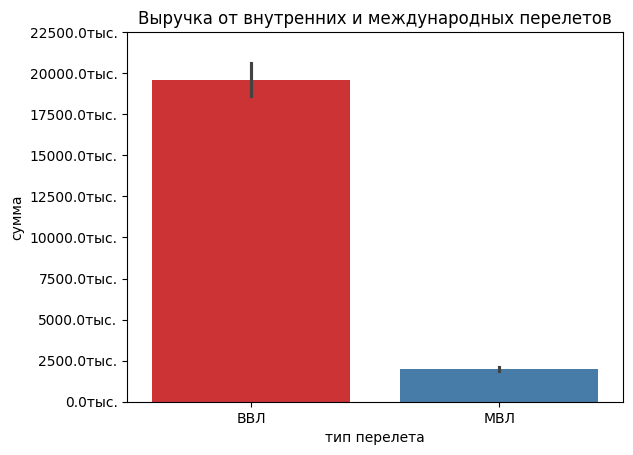

In [44]:
sns.barplot(table5, x='тип перелета', y ='сумма', palette='Set1', estimator='sum')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Выручка от внутренних и международных перелетов')
plt.show()

Переходим к столбцу способа покупки билета

In [45]:
table6 = df.groupby(['способ покупки', 'дата совершения перелета'])['сумма'].sum().reset_index()
table6

,способ покупки,дата совершения перелета,сумма
0,OFFLINE,2021-10-02,3950
1,OFFLINE,2021-10-03,3680
2,OFFLINE,2021-10-04,3120
3,OFFLINE,2021-10-05,8860
4,OFFLINE,2021-10-06,10330
...,...,...,...
734,ONLINE,2022-10-01,39690
735,ONLINE,2022-10-02,39110
736,ONLINE,2022-10-03,28760
737,ONLINE,2022-10-04,25890


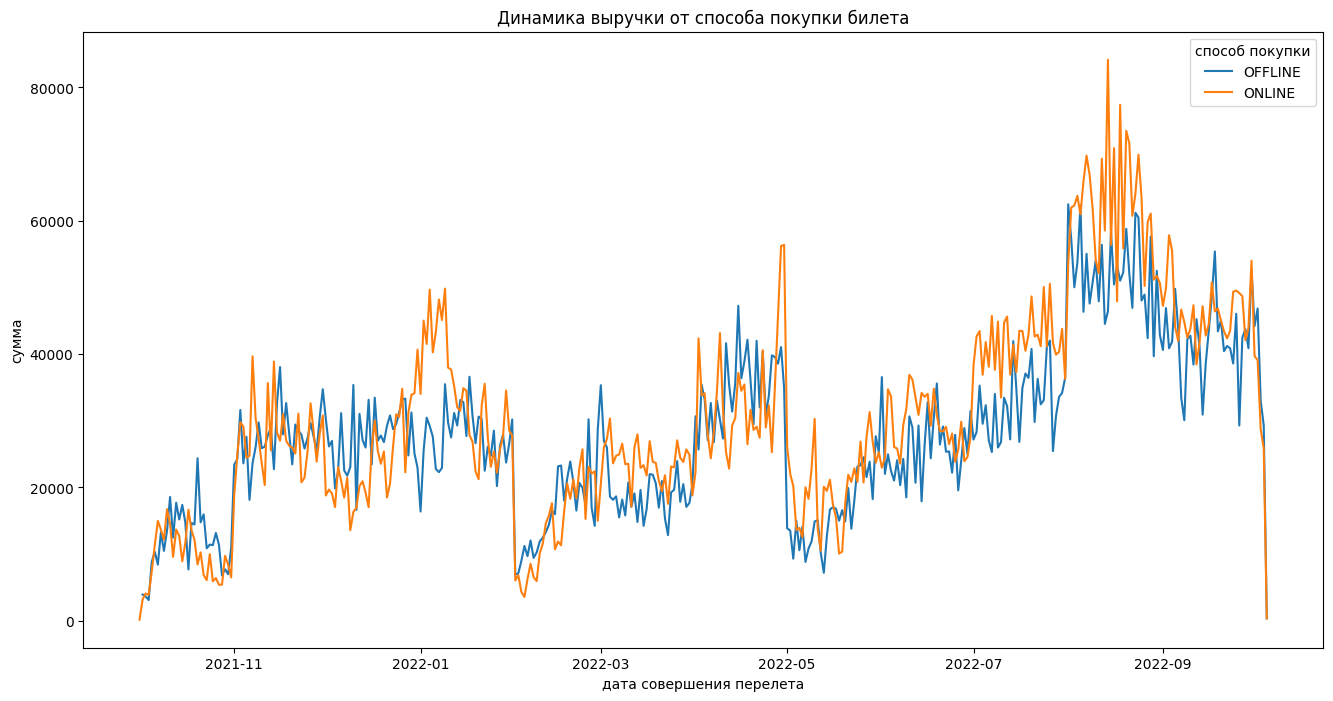

In [46]:
plt.figure(figsize=(16,8))
sns.lineplot(table6, x ='дата совершения перелета', y='сумма', hue='способ покупки')
plt.title('Динамика выручки от способа покупки билета')
plt.show()

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\24541163.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(table6, x='способ покупки', y ='сумма', palette='Set1', estimator='sum')


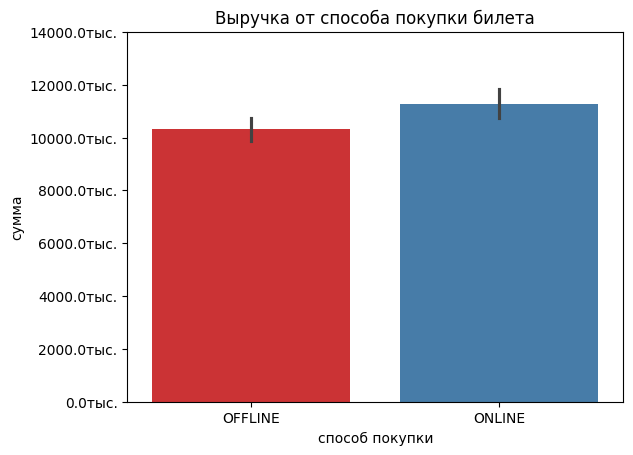

In [47]:
sns.barplot(table6, x='способ покупки', y ='сумма', palette='Set1', estimator='sum')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Выручка от способа покупки билета')
plt.show()

Видим, что по динамике выручки относительно программы лояльности компания всегда получала большую выручку от пассажиров, которые её не имели. Также за весь период выручка от внутренних перелетов была больше, чем от международных, потому что их по общему числу было всегда меньше. При этом по выручка в динамике по способам покупки билета всегда была примерно равной.

Постройте общие отчеты по выручке по типам пассажиров, по типам перелета, по способам покупки, по программам лояльности. Визуализируйте каждый отчет. Решение о детализации отчетов примите самостоятельно.

Построим отчет по выручке по типам пассажиров

In [48]:
table7 = df.groupby('тип пассажиров')['сумма'].sum().reset_index()
table7

,тип пассажиров,сумма
0,AD,20260530
1,CHD,1333430
2,INF,9730


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\2993443972.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(table7, x='тип пассажиров', y='сумма', estimator='sum', palette='cool')


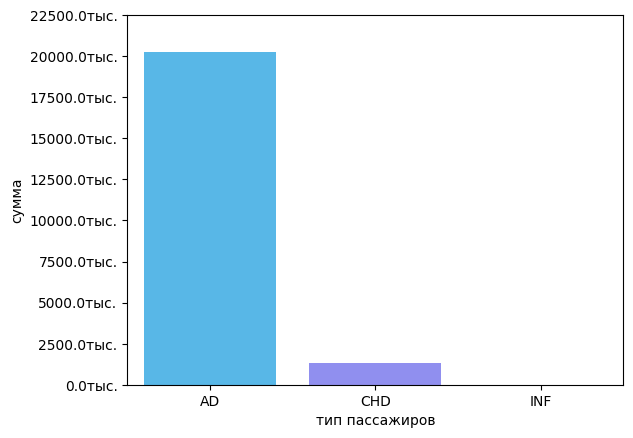

In [49]:
sns.barplot(table7, x='тип пассажиров', y='сумма', estimator='sum', palette='cool')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.show()

Распределим по годам

In [50]:
table8 = df.groupby(['год', 'тип пассажиров'])['сумма'].sum().reset_index()
table8

,год,тип пассажиров,сумма
0,2021,AD,4657970
1,2021,CHD,275040
2,2021,INF,3340
3,2022,AD,15602560
4,2022,CHD,1058390
5,2022,INF,6390


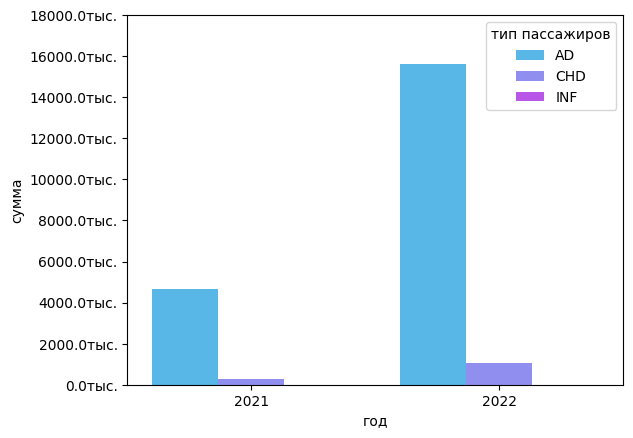

In [51]:
sns.barplot(table8, x='год', y='сумма', hue='тип пассажиров', estimator='sum', palette='cool')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.show()

Теперь сделаем отчет по выручке по типам перелета

In [52]:
table9 = df.groupby('тип перелета')['сумма'].sum().reset_index()
table9

,тип перелета,сумма
0,ВВЛ,19610480
1,МВЛ,1993210


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\2529909838.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(table9, x='тип перелета', y='сумма', estimator='sum', palette='cool')


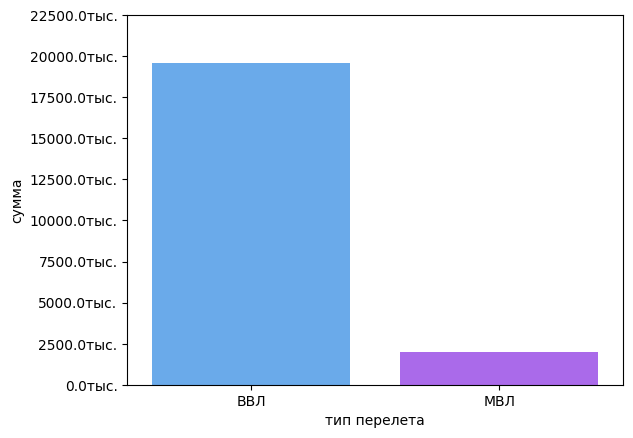

In [53]:
sns.barplot(table9, x='тип перелета', y='сумма', estimator='sum', palette='cool')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.show()

Распределим по годам

In [54]:
table10 = df.groupby(['год', 'тип перелета'])['сумма'].sum().reset_index()
table10

,год,тип перелета,сумма
0,2021,ВВЛ,4020490
1,2021,МВЛ,915860
2,2022,ВВЛ,15589990
3,2022,МВЛ,1077350


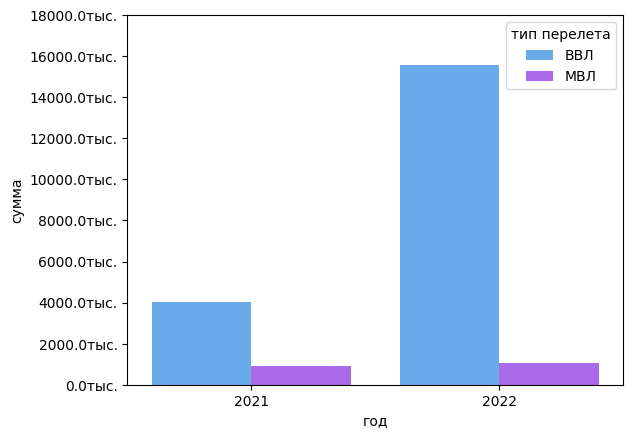

In [55]:
sns.barplot(table10, x='год', y='сумма', hue='тип перелета', estimator='sum', palette='cool')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.show()

Можно построить какой-нибудь сложный график: совместить типы пассажиров, года, тип перелета. 

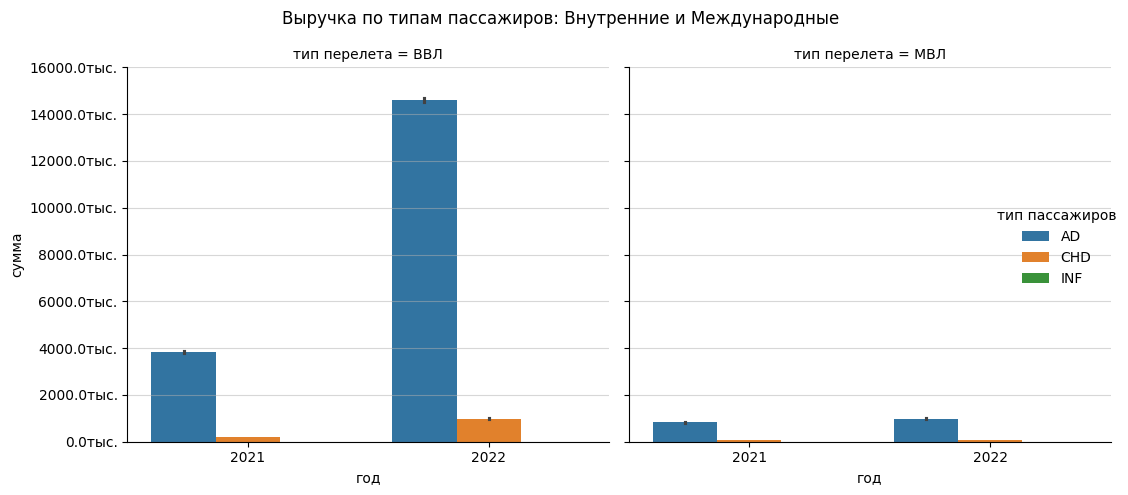

In [56]:
graph = sns.catplot(df, x='год', y='сумма', hue='тип пассажиров', col='тип перелета', kind='bar', estimator='sum')
for ax in graph.axes.flatten():
    ax.grid(True, alpha=0.5, axis='y')
graph.figure.suptitle('Выручка по типам пассажиров: Внутренние и Международные')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.tight_layout()
plt.show()

Для таких графиков можно делать конкатенацию столбцов или использовать синтаксис sns.catplot(   col = ...). ИЛИ же можно и то, и то совместить, и построить еще что-то более сложное.

Сделаем отчет по выручке по наличию программы лояльности

In [57]:
table11 = df.groupby('наличие программы лояльности')['сумма'].sum().reset_index()
table11

,наличие программы лояльности,сумма
0,есть,8222390
1,нет,13381300


Распределим по годам

In [58]:
table12 = df.groupby(['наличие программы лояльности', 'год'])['сумма'].sum().reset_index()
table12

,наличие программы лояльности,год,сумма
0,есть,2021,1958140
1,есть,2022,6264250
2,нет,2021,2978210
3,нет,2022,10403090


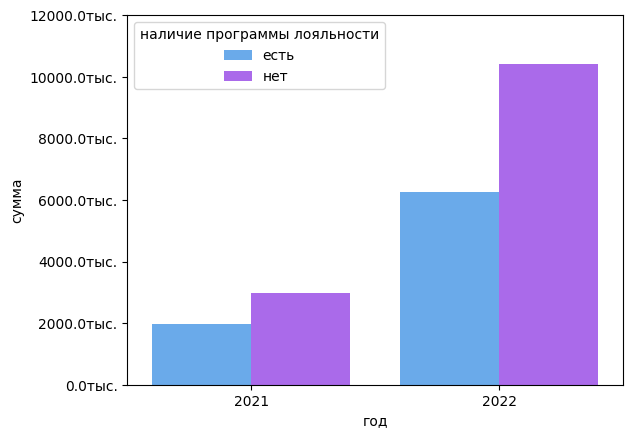

In [59]:
sns.barplot(table12, x='год', y='сумма', hue='наличие программы лояльности', estimator='sum', palette='cool')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.show()

Видим, что выручка идет больше от тех людей, у которых нет программы лояльности. Это логично, потому что клиенты без программы лояльности обычно покупают билеты дороже, реже пользуясь скидками.

Общий вывод: авиакомпания получает бОльшую выручку от граждан, у которых нет программы лояльности, поскольку такие граждане больше платят за перелёт. Большинство пассажиров - это взрослые люди, выручка по младенцам почти равна нулю. Сильное преимущество у внутренних перелётов перед международными, в связи с чем и выручка от внутренних перелётов намного больше. На это есть несколько причин: во-первых, это санкции с 2022 года, понизившие спрос на международные перелёты; во-вторых, Россия гигантская страна, поэтому имеется огромный спрос на ВВЛ; в-третьих, большинство авиакомпаний сами по себе ориентированы на внутренние перевозки и тд. 

Отдельно стоит сказать, что выручка по способам покупки почти одинаковая, это кажется странным. Лично я даже не знаю, как покупать билеты оффлайн. 
В качестве причин интернет говорит мне о том, что оффлайн билеты стоят дороже, поскольку в интернете людям сразу предлагают самые дешевые доступные билеты. Еще оффлайн билеты часто покупаются в самих аэропортах за несколько часов до вылета, поэтому цена на них высокая.

3.2 Исследуйте выручку, примите решение об исключении выбросов для дальнейшего исследования, руководствуясь минимизацией потерь в данных.
     

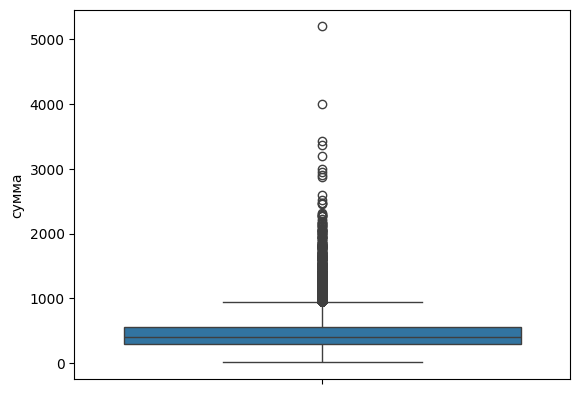

In [60]:
sns.boxplot(df['сумма'])
plt.show()

видим, что есть довольно много выбросов

In [61]:
df[df['сумма'] > 3000]

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал
9537,2022-03-29,2022-04-08,AD,3190,NSK,MOW,ВВЛ,нет,OFFLINE,2022,March,3,1,1
19267,2022-09-27,2022-09-29,AD,3430,MOW,EVN,МВЛ,нет,ONLINE,2022,September,9,1,3
19313,2022-09-28,2022-09-29,AD,4000,MOW,IST,МВЛ,есть,OFFLINE,2022,September,9,2,3
26743,2021-12-28,2021-12-29,AD,5200,MOW,PEE,ВВЛ,нет,OFFLINE,2021,December,12,1,4
38552,2022-03-30,2022-03-31,AD,3360,MOW,UUD,ВВЛ,нет,OFFLINE,2022,March,3,2,1


In [62]:
df['сумма'].describe()

count    49365.000000
mean       437.631723
std        214.604891
min         10.000000
25%        290.000000
50%        400.000000
75%        550.000000
max       5200.000000
Name: сумма, dtype: float64

Посчитаем верхнюю границу уса.


In [63]:
df['сумма'].describe()['75%'] + 1.5 * (df['сумма'].describe()['75%'] - df['сумма'].describe()['25%'])

np.float64(940.0)

In [64]:
vibrosy = df.query('`сумма` > 940')['сумма']
vibrosy

14       1090
79       1820
117      1030
164       960
213      2000
         ... 
48994    1310
49100     960
49191     970
49334     950
49337     960
Name: сумма, Length: 987, dtype: int64

Давайте теперь посмотрим, сколько будет выбросов, когда мы посчитаем через 3*sigma

In [65]:

df['сумма'].describe()['50%'] + 3 * df['сумма'].describe()['std']


np.float64(1043.8146740680672)

In [66]:
vibrosy1 = df.query('`сумма` > 1043.8146740680672')['сумма']
vibrosy1

14       1090
79       1820
213      2000
396      1140
519      1200
         ... 
48607    1470
48635    1700
48854    1260
48970    1550
48994    1310
Name: сумма, Length: 564, dtype: int64

Здесь выбросов 564. В данном случае данные не распределены нормально, поэтому сколько это число равно в процентах от общих данных без подсчетов сказать нельзя. Я уберу выбросы, рассчитанные через значение верхнего уса, поскольку их там немного больше.

In [67]:
listt = vibrosy.tolist()

In [68]:
df = df[~df['сумма'].isin(listt)]

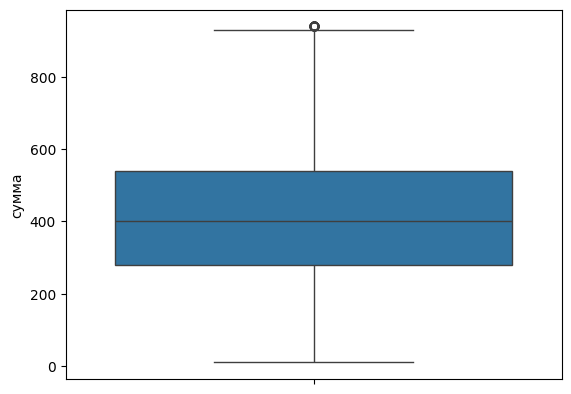

In [69]:
sns.boxplot(df['сумма'])
plt.show()

Видим, что есть очень дорогие билеты. Всего лишь от 5 билетов из всего датасета выручка составила более 3000 у.е. Наверное, эти люди покупали билеты на очень хорошие места, при этом делали это довольно поздно. Кстати, во всех пяти перелетах у нас есть Москва. 


Цена билетов не имеет нормального распределения, и это абсолютно логично, поскольку она сильно варьируется от времени продажи и от сезонности. Ниже я об этом подробнее писал, когда исследовал сезонность продаж

 3.3 Исследуйте сезонность продаж. Дополнительно проверьте гипотезу о том, что выручка от продаж осенью и зимой отличается. Исследуйте выручку и число продаж по месяцам, проверьте корреляцию.

In [70]:
season = {12: 'зима', 1: 'зима', 2: 'зима', 3: 'весна', 4: 'весна', 5: 'весна', 6: 'лето', 7: 'лето', 8: 'лето', 9: 'осень', 10: 'осень', 11:  'осень'}
df['сезон'] = df['месяц'].map(season)
df

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\2091808974.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['сезон'] = df['месяц'].map(season)


,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал,сезон
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,нет,ONLINE,2021,December,12,1,4,зима
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,нет,OFFLINE,2021,December,12,4,4,зима
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,есть,ONLINE,2021,November,11,6,4,осень
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,нет,ONLINE,2021,December,12,2,4,зима
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,есть,OFFLINE,2021,December,12,2,4,зима
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49360,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,нет,ONLINE,2022,June,6,5,2,лето
49361,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,нет,OFFLINE,2022,June,6,0,2,лето
49362,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,есть,ONLINE,2022,June,6,6,2,лето
49363,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,нет,OFFLINE,2022,June,6,6,2,лето


In [71]:
table14 = df.groupby('сезон')['сумма'].sum().reset_index()
table14


,сезон,сумма
0,весна,5346720
1,зима,4267730
2,лето,6207480
3,осень,4590790


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\4019028008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(table14, x='сезон', y='сумма', palette='Set1', estimator='sum')


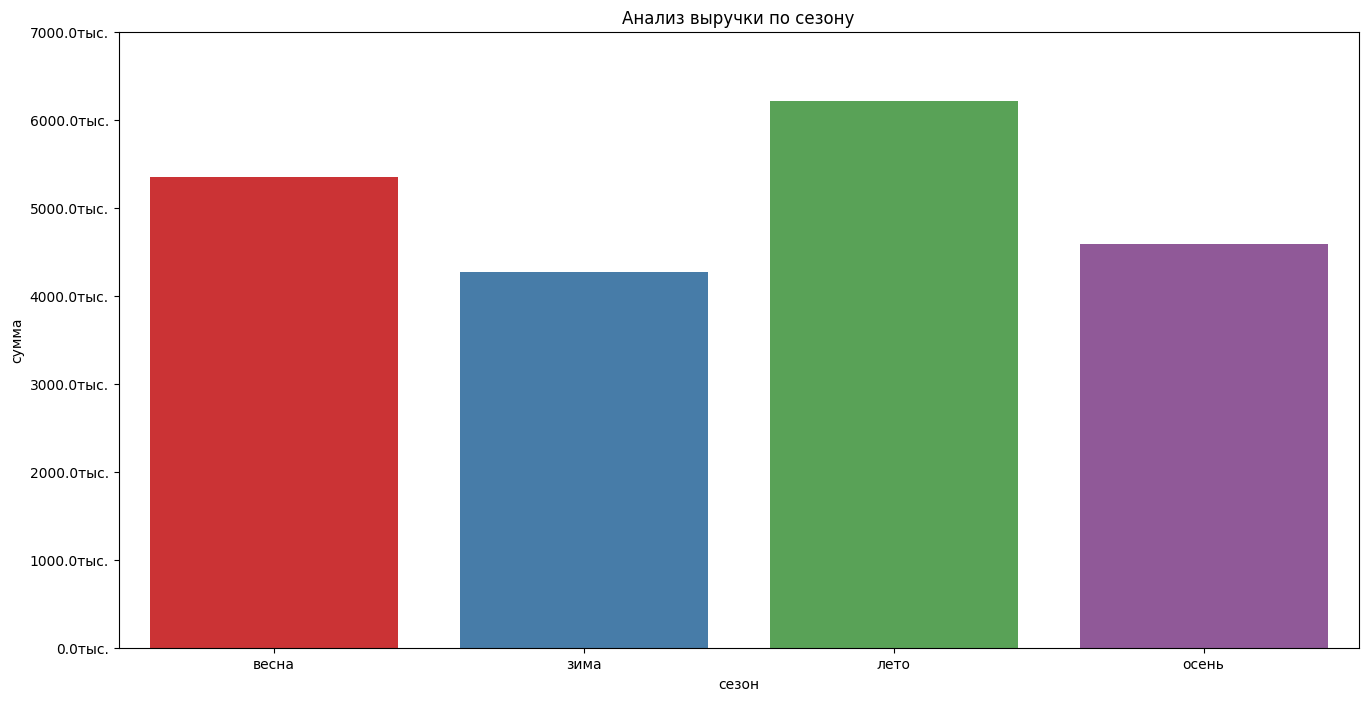

In [72]:
plt.figure(figsize=(16,8))
sns.barplot(table14, x='сезон', y='сумма', palette='Set1', estimator='sum')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Анализ выручки по сезону')
plt.show()

In [73]:
order = [ 'November','December','January','February','March','April', 'May','June','July','August','September','October']

df['название месяца'] = pd.Categorical(df['название месяца'], categories=order, ordered=True)

table13 = df.groupby('название месяца')['сумма'].sum().reset_index().sort_values('название месяца')
table13
# функция pd.Categorial() работает благодаря sort_values(): без этого код бы вывел данные 'по умолчанию'
# В пункте 3.1 я уже делал такую же таблицу, только сортировал месяцы через reindex()
# Теперь числа уже после чисток немного другие



C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\848801029.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['название месяца'] = pd.Categorical(df['название месяца'], categories=order, ordered=True)
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\848801029.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table13 = df.groupby('название месяца')['сумма'].sum().reset_index().sort_values('название месяца')


,название месяца,сумма
0,November,1766940
1,December,1666010
2,January,1304090
3,February,1297630
4,March,1759960
5,April,1934200
6,May,1652560
7,June,1538600
8,July,2447960
9,August,2220920


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1190416164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(table13, x='название месяца', y='сумма', palette='cool', estimator='sum')


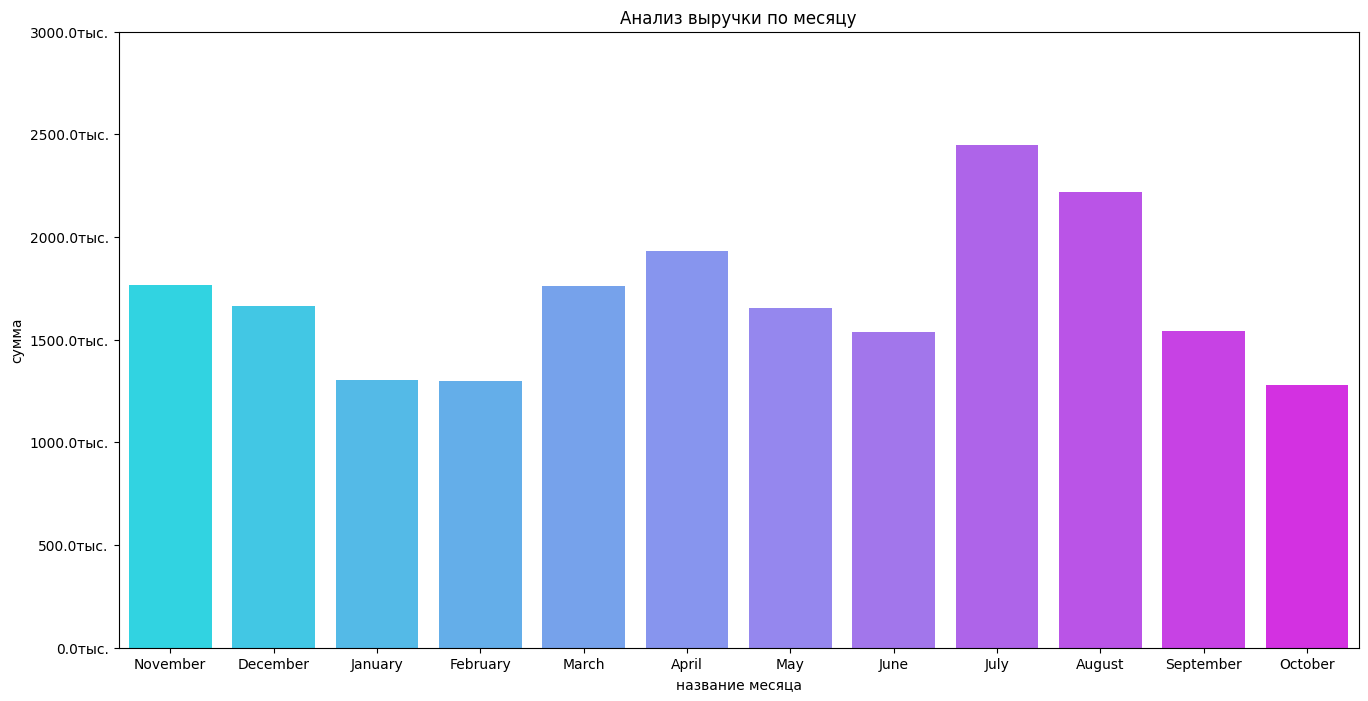

In [74]:
plt.figure(figsize=(16,8))
sns.barplot(table13, x='название месяца', y='сумма', palette='cool', estimator='sum')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Анализ выручки по месяцу')
plt.show()

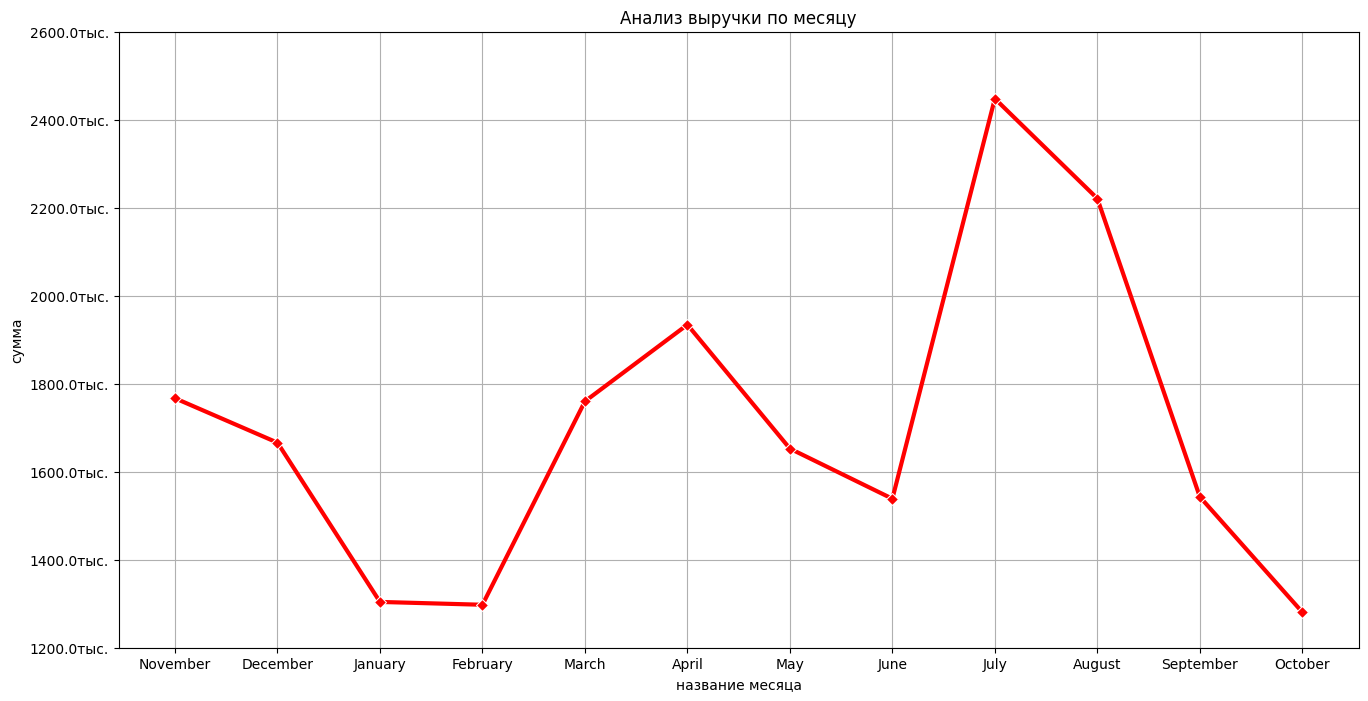

In [75]:
plt.figure(figsize=(16,8))
sns.lineplot(table13, x='название месяца', y='сумма', marker='D', linewidth=3, color='red')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.grid(True)
plt.title('Анализ выручки по месяцу')
plt.show()

Видим, что здесь лидирует по выручке июль. То есть в июле авиакомпания получила больше всего прибыли за продажу билетов

Следующая таблица table14 отличается от table13 только тем, что агрегирующая функция это count(), а не sum(). То есть я теперь просто смотрю на количество продаж по месяцам

In [76]:
order = [ 'November','December','January','February','March','April', 'May','June','July','August','September','October']

df['название месяца'] = pd.Categorical(df['название месяца'], categories=order, ordered=True)

table15 = df.groupby('название месяца')['сумма'].count().reset_index().sort_values('название месяца')
table15

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1145666258.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['название месяца'] = pd.Categorical(df['название месяца'], categories=order, ordered=True)
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1145666258.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table15 = df.groupby('название месяца')['сумма'].count().reset_index().sort_values('название месяца')


,название месяца,сумма
0,November,5109
1,December,4490
2,January,3552
3,February,3415
4,March,4275
5,April,3887
6,May,3565
7,June,3287
8,July,5093
9,August,4571


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\992706983.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(table15, x='название месяца', y='сумма', palette='Set1', estimator='sum')


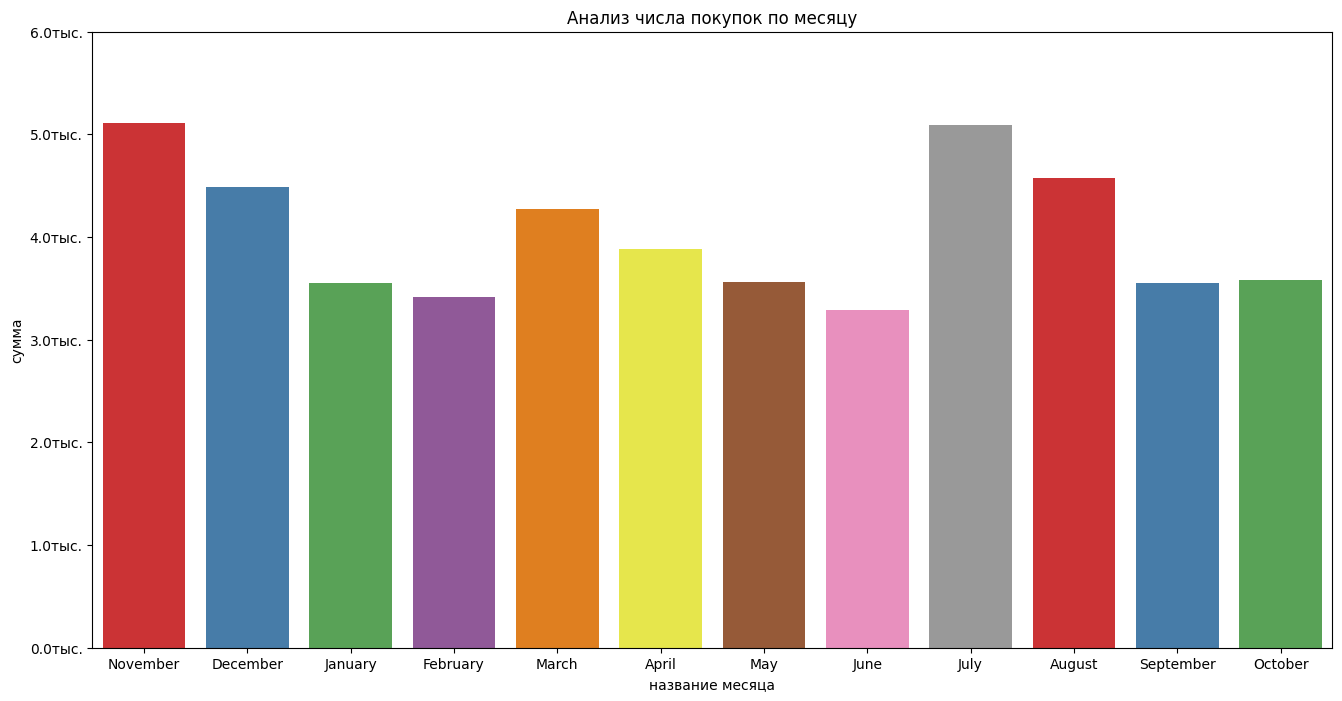

In [77]:
plt.figure(figsize=(16,8))
sns.barplot(table15, x='название месяца', y='сумма', palette='Set1', estimator='sum')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Анализ числа покупок по месяцу')
plt.show()

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1212793100.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(table15, x='название месяца', y='сумма', linewidth=2, marker='o', palette='Set1', color='red')


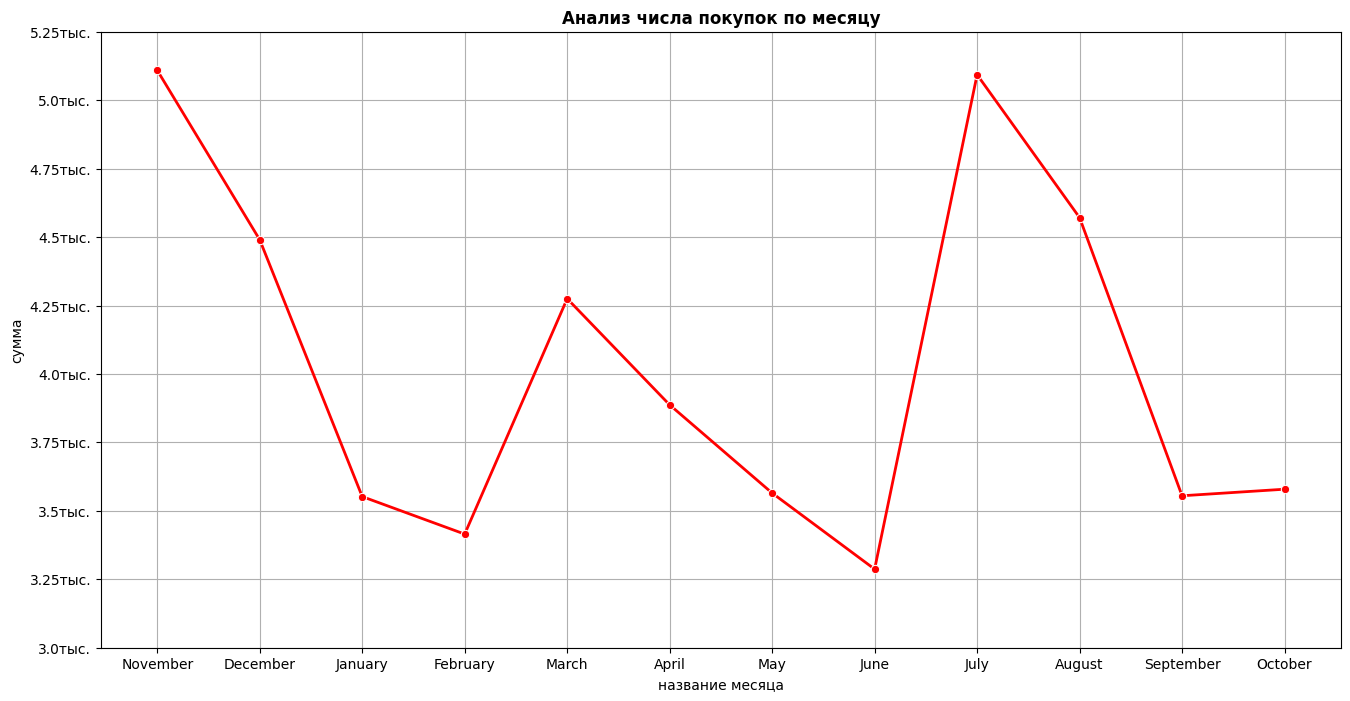

In [78]:
plt.figure(figsize=(16,8))
sns.lineplot(table15, x='название месяца', y='сумма', linewidth=2, marker='o', palette='Set1', color='red')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Анализ числа покупок по месяцу', fontweight='bold')
plt.grid()
plt.show()

Тут можно заметить, что лидирует ноябрь по количеству покупок. Июль и август сохраняют высокие позиции
Скорее всего, в ноябре большинство билетов было куплено на новый год. В конце 2021 года Россия еще не начала Специальную Военную операцию, с полётами было попроще. В связи с этим отдельно сейчас рассмотрим международные полёты в декабре 2021 - январе 2022 года. После этого проверим гипотезу, указанную в условии задания

In [79]:
sum_nov = df[df['название месяца'] == "November"]['сумма'].mean()
sum_nov

np.float64(345.8485026423958)

In [80]:
sum_july = df[df['название месяца'] == "July"]['сумма'].mean() 
sum_july

np.float64(480.65187512271746)

In [81]:
sum_aug = df[df['название месяца'] == "August"]['сумма'].mean()
sum_aug

np.float64(485.8718004812951)

In [82]:
winter = df[df['сезон'] == 'зима'][['тип перелета', 'сумма']]
winter
summer = df[df['сезон'] == 'лето'][['тип перелета', 'сумма']]
summer

,тип перелета,сумма
553,ВВЛ,520
554,ВВЛ,250
555,ВВЛ,270
556,ВВЛ,390
557,ВВЛ,210
...,...,...
49360,ВВЛ,480
49361,ВВЛ,270
49362,ВВЛ,230
49363,ВВЛ,270


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\3777016925.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\3777016925.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])


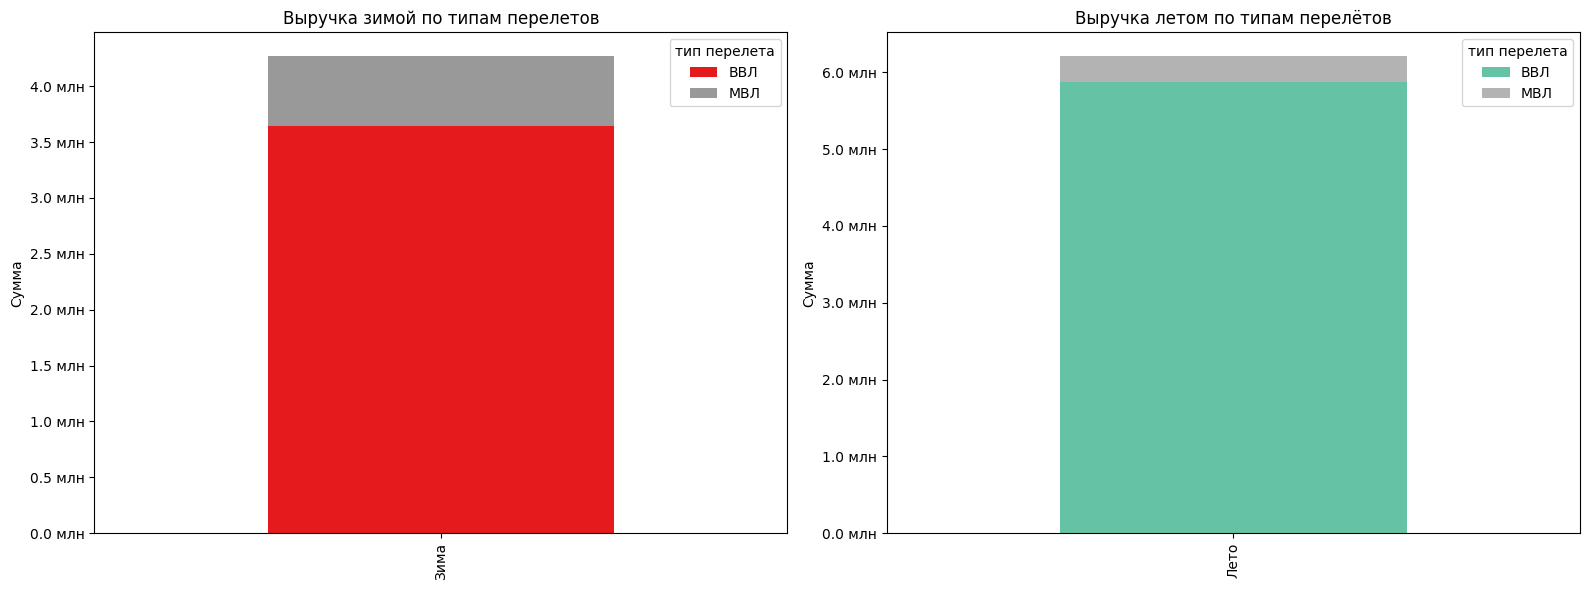

In [83]:
winter_pivot = winter.pivot_table(index=None, columns='тип перелета', values='сумма', aggfunc='sum')
summer_pivot = summer.pivot_table(index=None, columns='тип перелета', values='сумма', aggfunc='sum')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
winter_pivot.plot(kind='bar', stacked=True, ax=ax1, colormap='Set1')
ax1.set_title('Выручка зимой по типам перелетов')
ax1.set_ylabel('Сумма')
ax1.set_xticklabels(['Зима'])
current = ax1.get_yticks()
ax1.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])


summer_pivot.plot(kind='bar', stacked=True, ax=ax2, colormap='Set2')
ax2.set_title('Выручка летом по типам перелётов')
ax2.set_ylabel('Сумма')
ax2.set_xticklabels(['Лето'])
current = ax2.get_yticks()
ax2.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])
plt.tight_layout()
plt.show()

Видим, что по дате покупки билета (не путать с датой перелета) выручка летом на полтора миллиона выше, чем зимой.

Постепенно переходя к проверке гипотезы, сделаем такие же графики для зимы и осени

In [84]:
winter = df[df['сезон'] == 'зима'][['тип перелета', 'сумма']]
winter
autumn = df[df['сезон'] == 'осень'][['тип перелета', 'сумма']]
autumn

,тип перелета,сумма
2,ВВЛ,390
5,МВЛ,250
7,ВВЛ,70
9,ВВЛ,280
11,ВВЛ,380
...,...,...
48991,ВВЛ,240
48992,ВВЛ,310
48993,МВЛ,440
48995,ВВЛ,400


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\36463874.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\36463874.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])


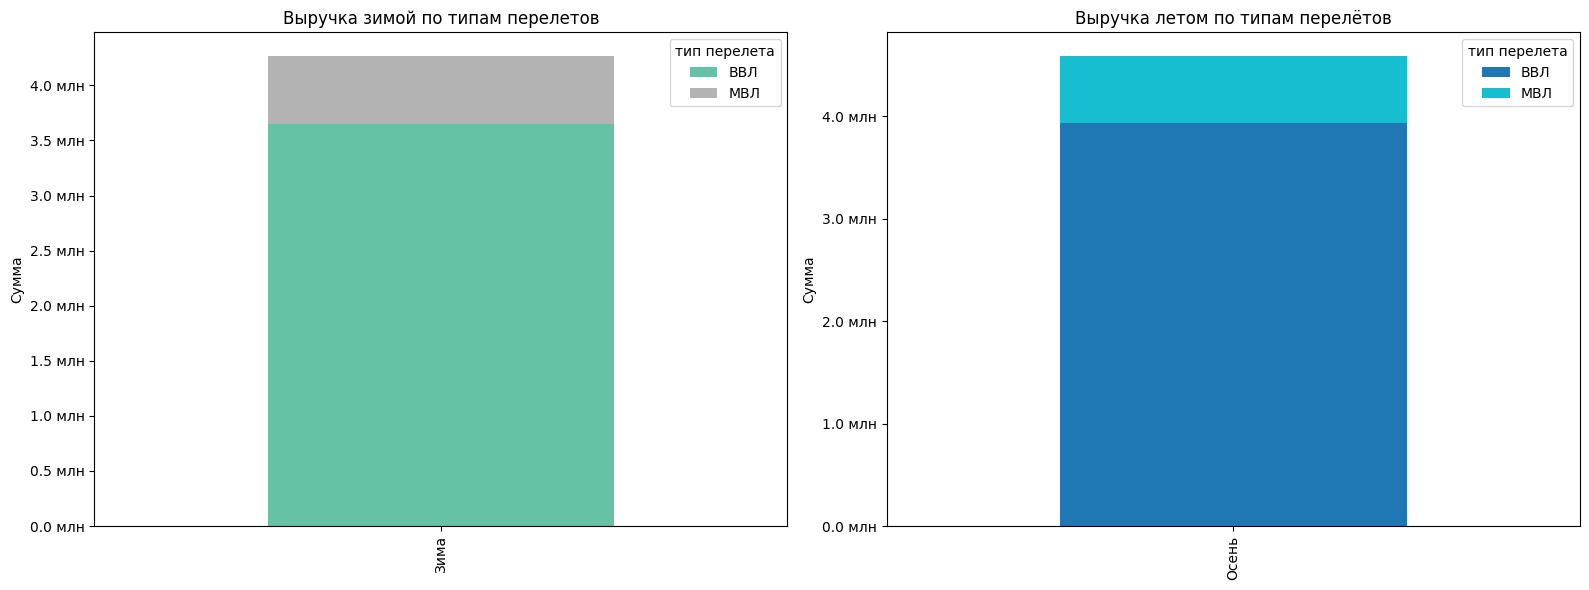

In [85]:
winter_pivot = winter.pivot_table(index=None, columns='тип перелета', values='сумма', aggfunc='sum')
autumn_pivot = autumn.pivot_table(index=None, columns='тип перелета', values='сумма', aggfunc='sum')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
winter_pivot.plot(kind='bar', stacked=True, ax=ax1, colormap='Set2')
ax1.set_title('Выручка зимой по типам перелетов')
ax1.set_ylabel('Сумма')
ax1.set_xticklabels(['Зима'])
current = ax1.get_yticks()
ax1.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])


autumn_pivot.plot(kind='bar', stacked=True, ax=ax2, colormap='tab10')
ax2.set_title('Выручка летом по типам перелётов')
ax2.set_ylabel('Сумма')
ax2.set_xticklabels(['Осень'])
current = ax2.get_yticks()
ax2.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])
plt.tight_layout()
plt.show()

Далее создадим датасеты с выручкой для зимы и осени, чтобы уже перейти к проверке гипотезы

In [86]:
winter = df[df['сезон'] == 'зима']['сумма']
autumn = df[df['сезон'] == 'осень']['сумма']


<Axes: ylabel='сумма'>

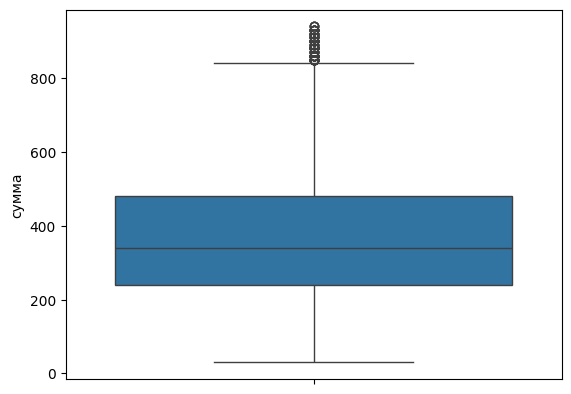

In [87]:
sns.boxplot(winter)

<Axes: ylabel='сумма'>

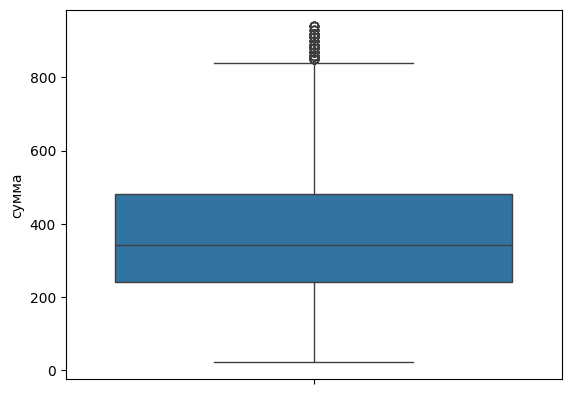

In [88]:
sns.boxplot(autumn)

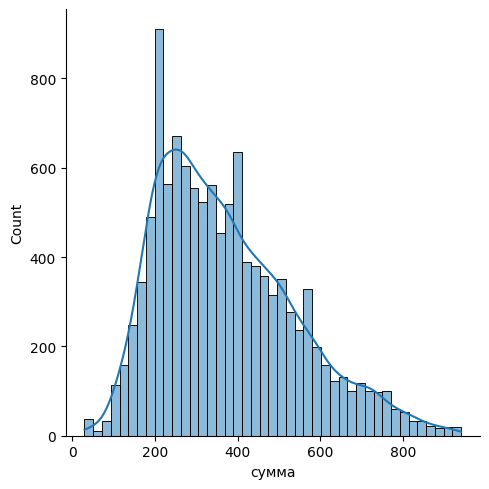

In [89]:
sns.displot(winter, kde=True)

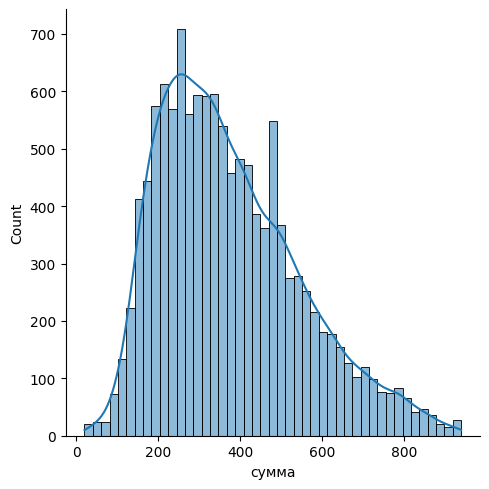

In [90]:
sns.displot(autumn, kde=True)

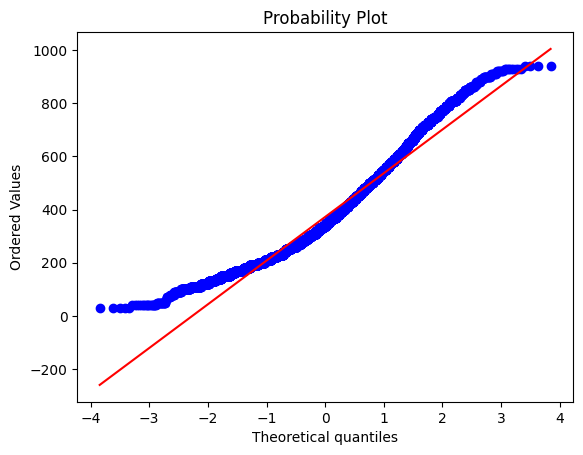

In [91]:
st.probplot(winter, dist='norm', plot=plt)
plt.show()

Распределение не похоже на нормальное


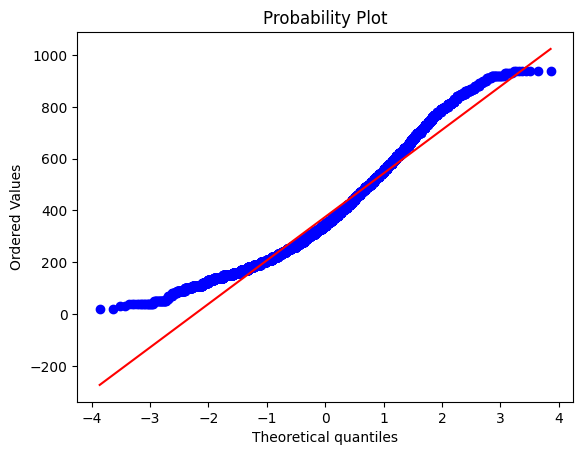

In [92]:
st.probplot(autumn, dist='norm', plot=plt)
plt.show()

Распределение также не похоже на нормальное

In [93]:
stat, p = st.shapiro(autumn)
alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')

1.305122497741752e-50 Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения


c:\Users\shopi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12243.
  res = hypotest_fun_out(*samples, **kwds)


In [94]:
stat, p = st.shapiro(winter)
alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')

1.0598453051786579e-49 Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения


c:\Users\shopi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11457.
  res = hypotest_fun_out(*samples, **kwds)


In [95]:
# H0: Средняя выручка от продаж зимой и осенью не отличается
# H1: Средняя выручка от продаж зимой и осенью отличается

In [96]:
results = st.ttest_ind(autumn, winter)
alpha = 0.05
print('Значение p-value:', results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью отличается')
else:
    print('Не отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью не отличается')

Значение p-value: 0.2631019012264758
Не отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью не отличается


Помимо т-теста, давайте проведем непараметрический тест

In [97]:
alpha = 0.05 # уровень статистической значимости

# если p-value окажется меньше него, отвергнем гипотезу

results = st.mannwhitneyu(winter, autumn)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью отличается ') 
else:
    print('Не удалось отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью не отличается') 

p-value: 0.4576401909557729
Не удалось отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью не отличается


Результат этого теста можно интерпретировать так: Значения в этих двух группах в среднем не отличаются

Теперь давайте удалим выбросы и заново проведем т-тест. Перед ним еще раз проверим, станут ли распределения нормальными или нет.

In [98]:
winter.describe()

count    11457.000000
mean       372.499782
std        168.195786
min         30.000000
25%        240.000000
50%        340.000000
75%        480.000000
max        940.000000
Name: сумма, dtype: float64

In [99]:
vybros = winter.describe()['75%'] + 1.5 * (winter.describe()['75%'] - winter.describe()['25%'])
vybros

np.float64(840.0)

In [100]:
winter = winter.reset_index()

In [101]:
winter = winter[winter['сумма'] <= 840].reset_index(drop=True)

In [102]:
autumn.describe()

count    12243.000000
mean       374.972637
std        171.656085
min         20.000000
25%        240.000000
50%        340.000000
75%        480.000000
max        940.000000
Name: сумма, dtype: float64

In [103]:
vybros = autumn.describe()['75%'] + 1.5 * (autumn.describe()['75%'] - autumn.describe()['25%'])
vybros

np.float64(840.0)

In [104]:
autumn = autumn.reset_index()

In [105]:
autumn = autumn[autumn['сумма'] <= 840].reset_index(drop=True)


Проведем теперь заново тесты qq и Шапиро-Уилка

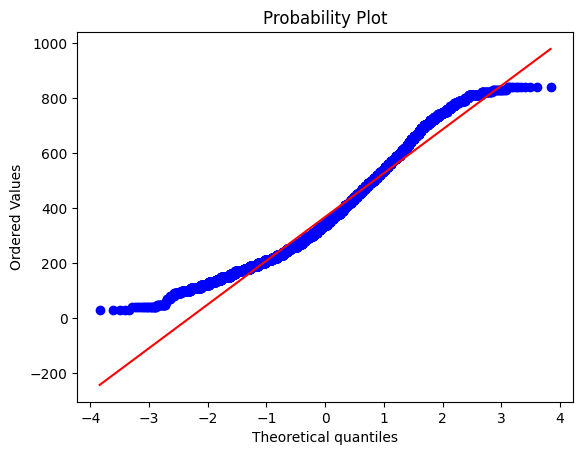

In [106]:
st.probplot(winter['сумма'], dist='norm', plot=plt)
plt.show()

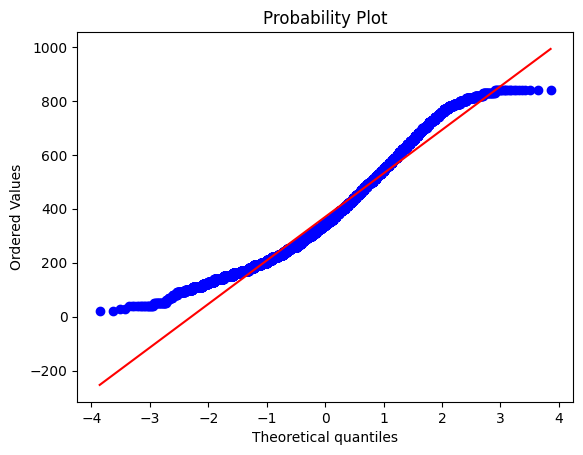

In [107]:
st.probplot(autumn['сумма'], dist='norm', plot=plt)
plt.show()

В принципе, особых изменений с графиками теста до выбросов не видим. 

In [108]:
stat, p = st.shapiro(autumn)
alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')

1.5166553769234746e-103 Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения


c:\Users\shopi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24238.
  res = hypotest_fun_out(*samples, **kwds)


In [109]:
stat, p = st.shapiro(winter)
alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')

3.019613239984765e-102 Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения


c:\Users\shopi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 22714.
  res = hypotest_fun_out(*samples, **kwds)


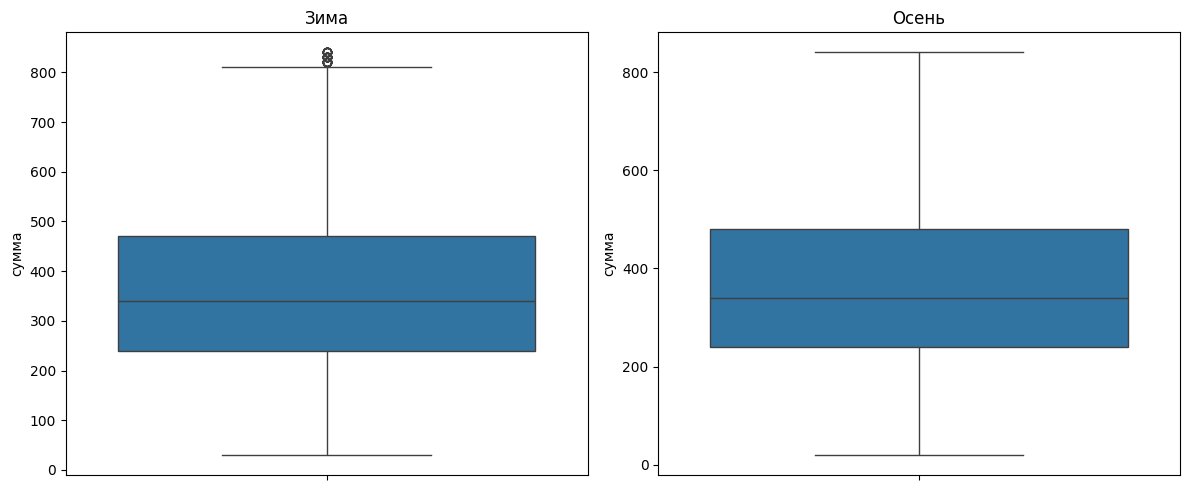

In [110]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=winter['сумма'], ax=ax1)
ax1.set_title("Зима")

sns.boxplot(y=autumn['сумма'], ax=ax2)
ax2.set_title("Осень")

plt.tight_layout()
plt.show()



In [111]:
winter = np.array(winter['сумма'])




In [112]:
winter

array([200, 610, 190, ..., 390, 650, 770], shape=(11357,))

In [113]:
autumn = np.array(autumn['сумма'])

In [114]:
results = st.ttest_ind(autumn, winter)
alpha = 0.05
print('Значение p-value:', results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью отличается')
else:
    print('Не отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью не отличается')

Значение p-value: 0.40446016809734564
Не отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью не отличается


В обоих т-тестах результаты совпали! Проведем еще раз непараметрический тест 

In [115]:
alpha = 0.05 # уровень статистической значимости

# если p-value окажется меньше него, отвергнем гипотезу

results = st.mannwhitneyu(winter, autumn)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью отличается ') 
else:
    print('Не удалось отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью не отличается') 

p-value: 0.5725354925701449
Не удалось отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью не отличается


По непараметрическому тесту результаты тоже совпали

Далее нам надо исследовать количество продаж и выручку по месяцам. Отдельные месяцы я так уже проверял. Теперь давайте сделаем общий отчет по этому подпункту.
Проверим корреляцию по всем месяцам.


In [116]:
kf = df.groupby('название месяца', as_index=False).agg(количество=('сумма', 'count'), выручка=('сумма', 'sum'))
kf
# as_index=False - позволяет не писать reset_index()
# код внутри agg не создает мультииндекс

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\4043305035.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kf = df.groupby('название месяца', as_index=False).agg(количество=('сумма', 'count'), выручка=('сумма', 'sum'))


,название месяца,количество,выручка
0,November,5109,1766940
1,December,4490,1666010
2,January,3552,1304090
3,February,3415,1297630
4,March,4275,1759960
5,April,3887,1934200
6,May,3565,1652560
7,June,3287,1538600
8,July,5093,2447960
9,August,4571,2220920


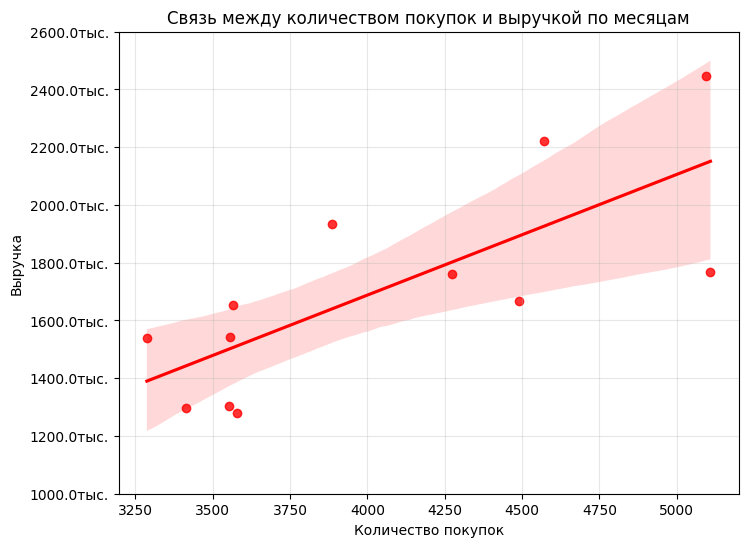

In [117]:
plt.figure(figsize=(8,6))
sns.regplot(kf, x='количество', y='выручка', color='red')
plt.xlabel('Количество покупок')
plt.ylabel('Выручка')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Связь между количеством покупок и выручкой по месяцам')
plt.grid(True, alpha=0.3)
plt.show()

In [118]:
kf[['количество', 'выручка']].corr()
# Метод corr() по умолчанию рассчитывает корреляцию Пирсона, то есть 

,количество,выручка
количество,1.000000,0.753043
выручка,0.753043,1.000000


Методом corr() еще можно рассчитать корреляцию рангов Спирмена, она, говоря очень по-простому, нужна в случаях, если график изогнутый и идет вверх. Также можно рассчитывать корреляцию Кендадла, из трёх из них она самая строгая, устойчивая к выбросам и маленьким выборкам. Рассчитаем дальше ещё две корреляции по двум методам, далее в выводе интепретируем результаты метода Пирсона.

In [119]:
print('Корреляция методом Спирмена:', kf[['количество', 'выручка']].corr(method='spearman'))
print('Корреляция методом Кендалла:', kf[['количество', 'выручка']].corr(method='kendall'))

Корреляция методом Спирмена:             количество  выручка
количество     1.00000  0.79021
выручка        0.79021  1.00000
Корреляция методом Кендалла:             количество   выручка
количество    1.000000  0.606061
выручка       0.606061  1.000000


Интерпретация корреляции Пирсона: связь между числом продаж по месяцам и выручкой тесная и прямая.

In [120]:
R2 = np.sqrt(0.753043)
R2

np.float64(0.8677805022008734)

Вариация количества покупок билетов на 86,8% объясняет вариацию выручки авиакомпании.

По графику выручки от 4-х времён года мы видим, что наиболее прибыльным для компании является лето, поскольку это период, когда многие летают отдыхать внутри страны. Также мы видели, что в топ-3 месяцев по количеству покупок билетов были ноябрь, август и июль. Осенний месяц идёт первым, поскольку многие покупают билеты на новый год, чтобы праздновать его как внутри страны, так и за рубежом. Не смотря на это, зима - это сезон с наименьшей выручкой из всех 4-х. Скорее всего, многие покупали билеты на новый год заранее, поэтому они не были очень дорогими. 


Корреляция между выручкой и числом продаж получилась тесной, значит эти показатели сильно связаны между собой.

Обязательно стоит отметить, что я проводил гипотезу по сезонам, которые были сделаны по месяцам, выручка которых считалась по дате покупки билета, а не по дате совершения перелёта. 


Ниже я перезапишу месяцы, сформированные по дате совершения перелета, визуализирую выручки по сезонам и месяцам, и проверю снова эту же гипотезу.


In [121]:
df['год'] = df['дата совершения перелета'].dt.year 
df['название месяца'] = df['дата совершения перелета'].dt.month_name()
df['месяц'] = df['дата совершения перелета'].dt.month
df['день недели'] = df['дата совершения перелета'].dt.dayofweek
df['квартал'] = df['дата совершения перелета'].dt.quarter

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\4159794402.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['год'] = df['дата совершения перелета'].dt.year
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\4159794402.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['название месяца'] = df['дата совершения перелета'].dt.month_name()
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\4159794402.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

In [122]:
season = {12: 'зима', 1: 'зима', 2: 'зима', 3: 'весна', 4: 'весна', 5: 'весна', 6: 'лето', 7: 'лето', 8: 'лето', 9: 'осень', 10: 'осень', 11:  'осень'}
df['сезон'] = df['месяц'].map(season)
df

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\2091808974.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['сезон'] = df['месяц'].map(season)


,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал,сезон
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,нет,ONLINE,2022,January,1,1,1,зима
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,нет,OFFLINE,2022,January,1,0,1,зима
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,есть,ONLINE,2022,January,1,1,1,зима
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,нет,ONLINE,2022,January,1,2,1,зима
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,есть,OFFLINE,2022,January,1,2,1,зима
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49360,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,нет,ONLINE,2022,June,6,2,2,лето
49361,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,нет,OFFLINE,2022,June,6,0,2,лето
49362,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,есть,ONLINE,2022,June,6,2,2,лето
49363,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,нет,OFFLINE,2022,June,6,1,2,лето


In [123]:
table14 = df.groupby('сезон')['сумма'].sum().reset_index()
table14

,сезон,сумма
0,весна,4339890
1,зима,4133430
2,лето,6990590
3,осень,4948810


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\4019028008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(table14, x='сезон', y='сумма', palette='Set1', estimator='sum')


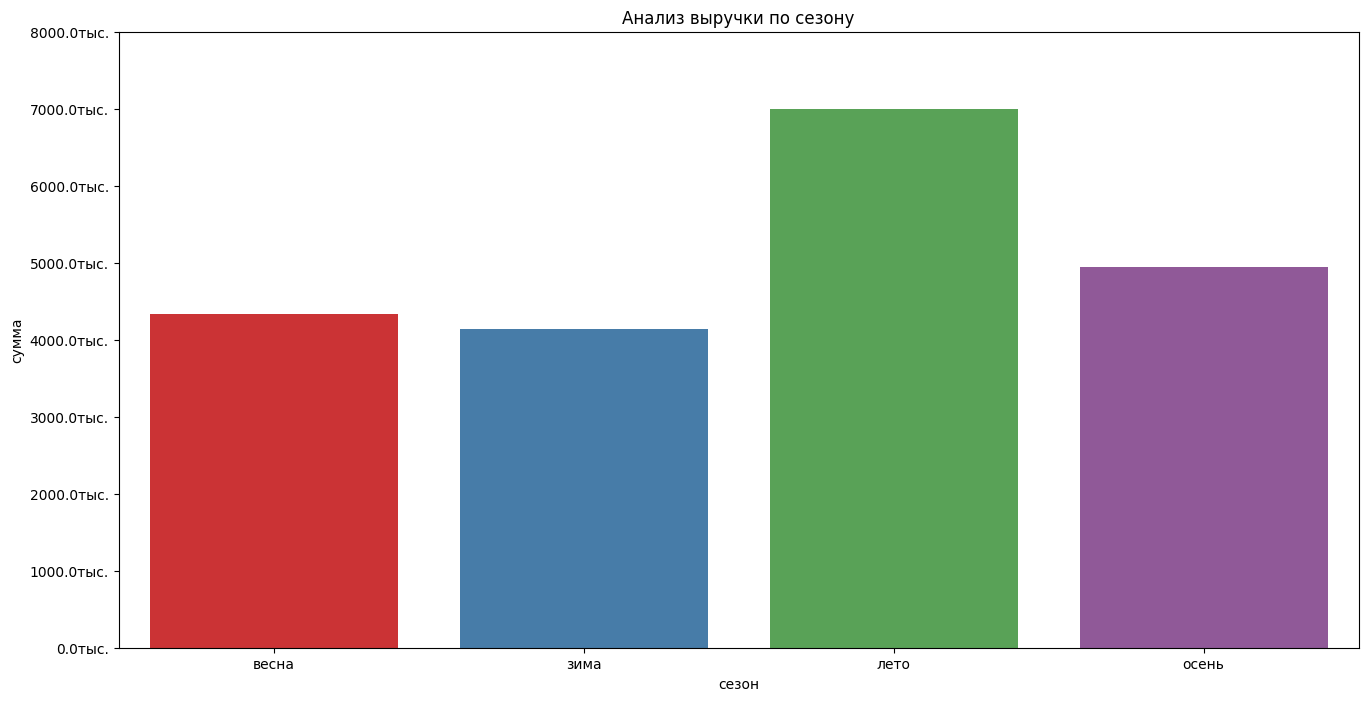

In [124]:
plt.figure(figsize=(16,8))
sns.barplot(table14, x='сезон', y='сумма', palette='Set1', estimator='sum')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Анализ выручки по сезону')
plt.show()

In [125]:
order = [ 'November','December','January','February','March','April', 'May','June','July','August','September','October']

df['название месяца'] = pd.Categorical(df['название месяца'], categories=order, ordered=True)

table13 = df.groupby('название месяца')['сумма'].sum().reset_index().sort_values('название месяца')
table13

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\678087212.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['название месяца'] = pd.Categorical(df['название месяца'], categories=order, ordered=True)
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\678087212.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table13 = df.groupby('название месяца')['сумма'].sum().reset_index().sort_values('название месяца')


,название месяца,сумма
0,November,1592670
1,December,1507430
2,January,1815020
3,February,810980
4,March,1286650
5,April,1961450
6,May,1091790
7,June,1605260
8,July,2158020
9,August,3227310


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\3526564633.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(table13, x='название месяца', y='сумма', palette='cool', estimator='sum')


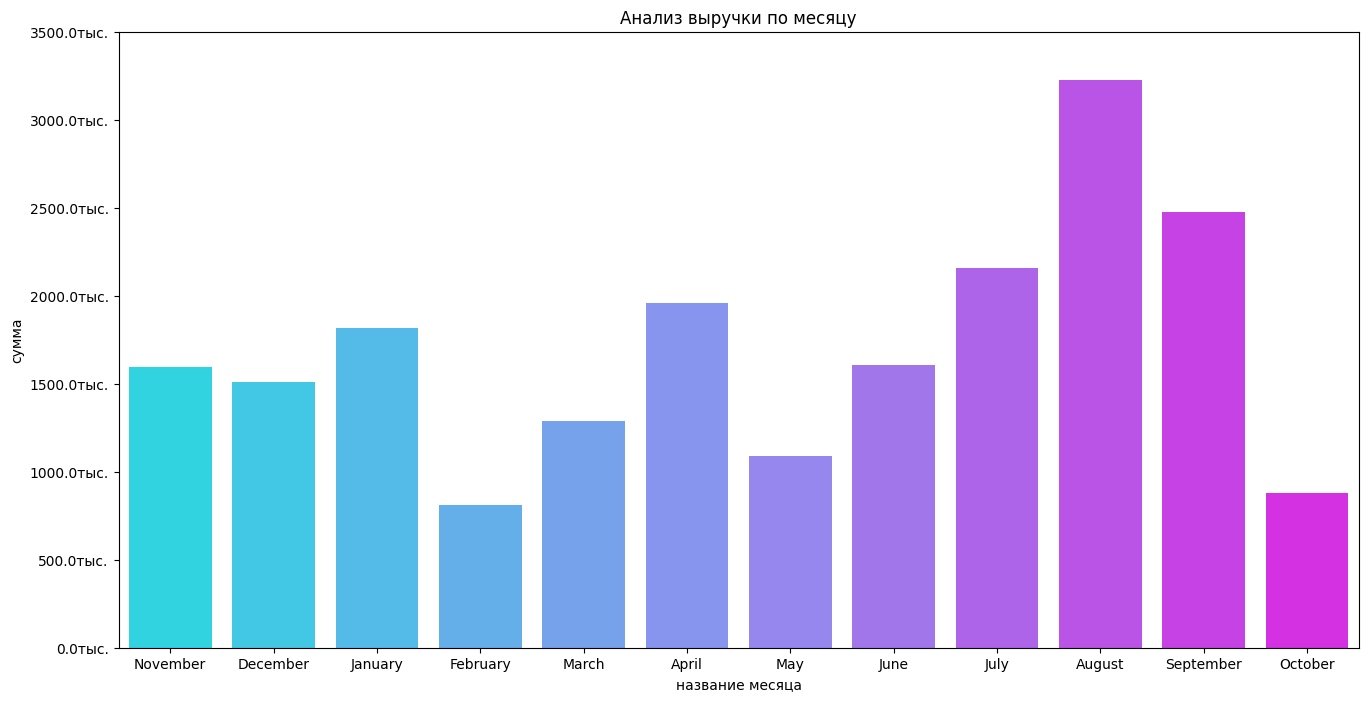

In [126]:
plt.figure(figsize=(16,8))
sns.barplot(table13, x='название месяца', y='сумма', palette='cool', estimator='sum')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Анализ выручки по месяцу')
plt.show()


In [127]:
order = [ 'November','December','January','February','March','April', 'May','June','July','August','September','October']

df['название месяца'] = pd.Categorical(df['название месяца'], categories=order, ordered=True)

table15 = df.groupby('название месяца')['сумма'].count().reset_index().sort_values('название месяца')
table15

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1145666258.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['название месяца'] = pd.Categorical(df['название месяца'], categories=order, ordered=True)
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1145666258.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table15 = df.groupby('название месяца')['сумма'].count().reset_index().sort_values('название месяца')


,название месяца,сумма
0,November,4511
1,December,4110
2,January,5059
3,February,2230
4,March,3599
5,April,4133
6,May,2420
7,June,3499
8,July,4463
9,August,6538


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\992706983.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(table15, x='название месяца', y='сумма', palette='Set1', estimator='sum')


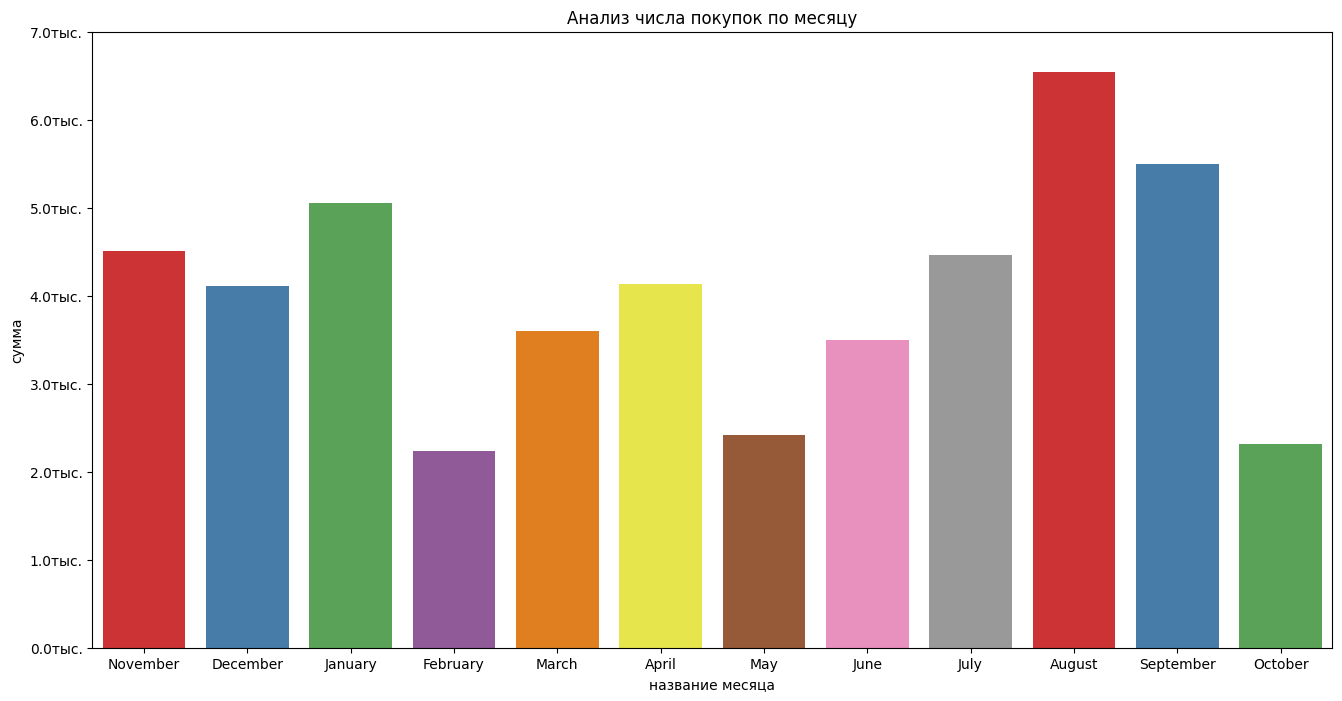

In [128]:
plt.figure(figsize=(16,8))
sns.barplot(table15, x='название месяца', y='сумма', palette='Set1', estimator='sum')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Анализ числа покупок по месяцу')
plt.show()

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1212793100.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(table15, x='название месяца', y='сумма', linewidth=2, marker='o', palette='Set1', color='red')


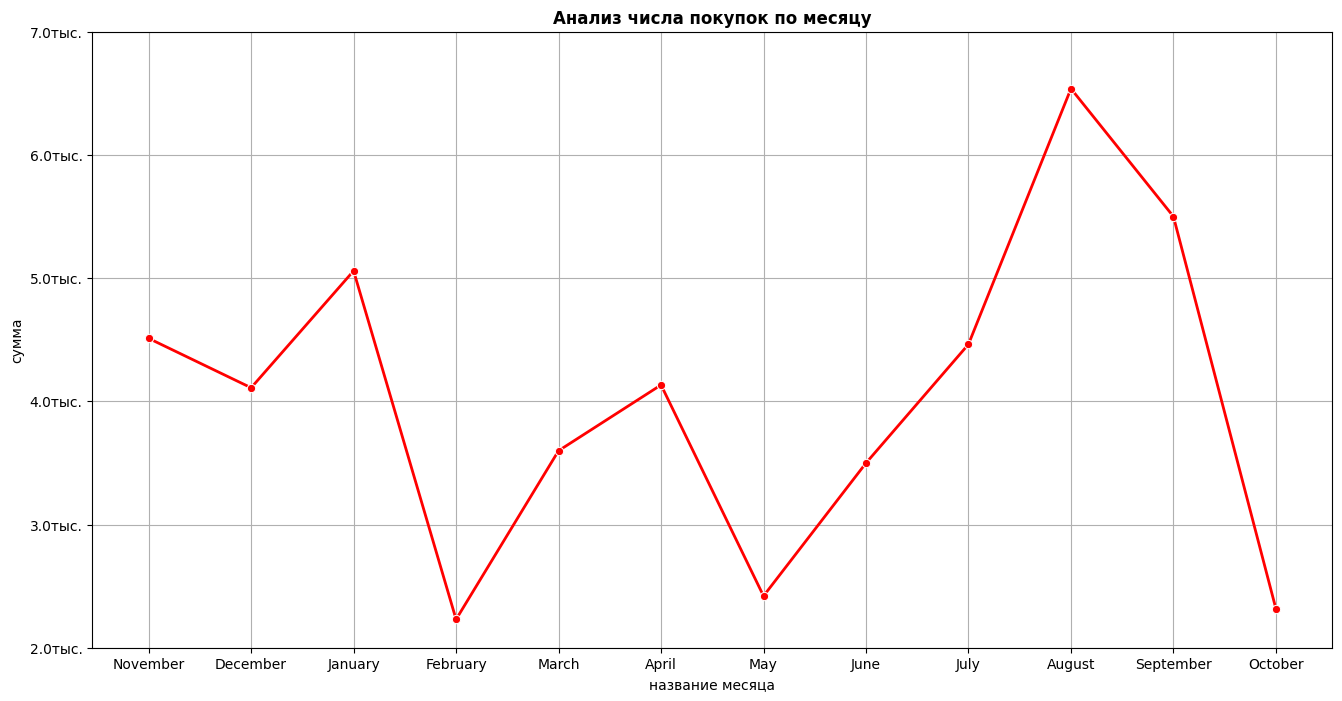

In [129]:
plt.figure(figsize=(16,8))
sns.lineplot(table15, x='название месяца', y='сумма', linewidth=2, marker='o', palette='Set1', color='red')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Анализ числа покупок по месяцу', fontweight='bold')
plt.grid()
plt.show()

In [130]:
winter = df[df['сезон'] == 'зима'][['тип перелета', 'сумма']]
winter
autumn = df[df['сезон'] == 'осень'][['тип перелета', 'сумма']]
autumn

,тип перелета,сумма
277,ВВЛ,170
278,ВВЛ,640
279,ВВЛ,410
280,МВЛ,600
281,ВВЛ,260
...,...,...
48663,ВВЛ,570
48664,ВВЛ,590
48665,ВВЛ,560
48666,ВВЛ,530


In [131]:
winter_pivot = winter.pivot_table(index=None, columns='тип перелета', values='сумма', aggfunc='sum')
autumn_pivot = autumn.pivot_table(index=None, columns='тип перелета', values='сумма', aggfunc='sum')


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1676949225.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1676949225.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])


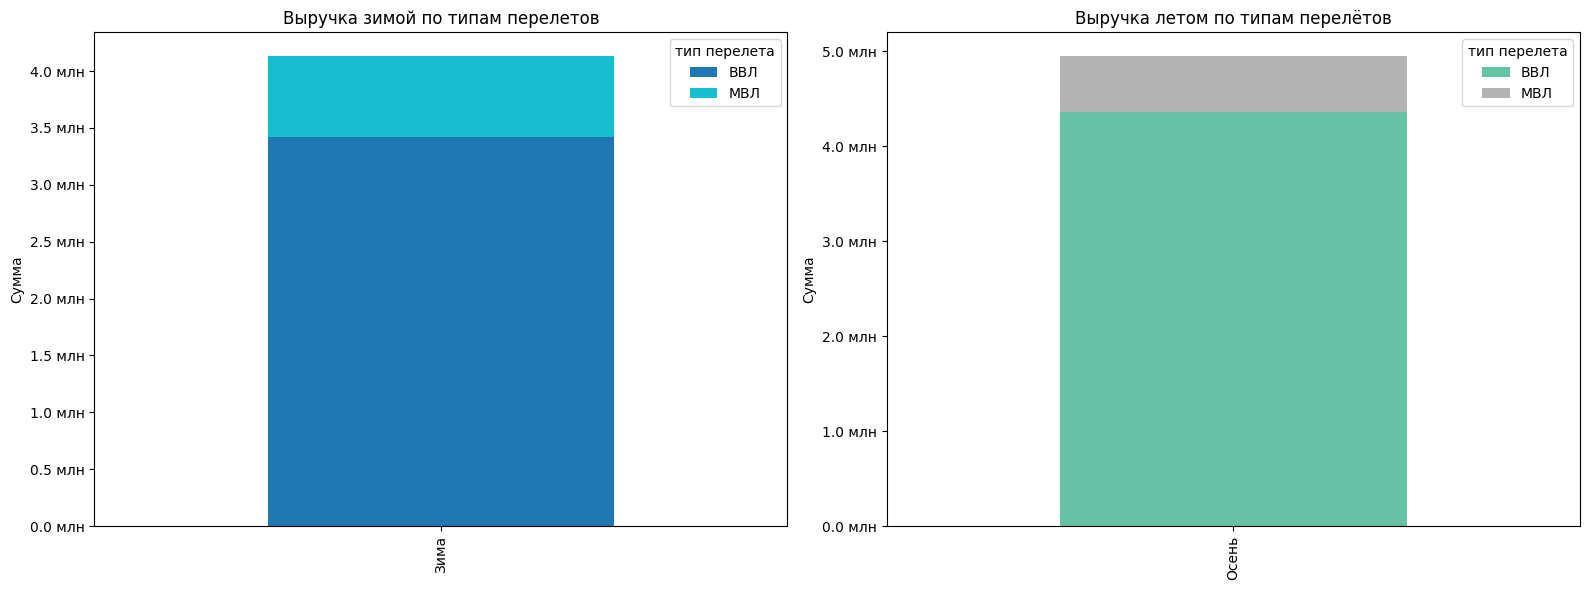

In [132]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
winter_pivot.plot(kind='bar', stacked=True, ax=ax1, colormap='tab10')
ax1.set_title('Выручка зимой по типам перелетов')
ax1.set_ylabel('Сумма')
ax1.set_xticklabels(['Зима'])
current = ax1.get_yticks()
ax1.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])


autumn_pivot.plot(kind='bar', stacked=True, ax=ax2, colormap='Set2')
ax2.set_title('Выручка летом по типам перелётов')
ax2.set_ylabel('Сумма')
ax2.set_xticklabels(['Осень'])
current = ax2.get_yticks()
ax2.set_yticklabels([f'{t/1000000:.1f} млн' for t in current])
plt.tight_layout()
plt.show()

In [133]:
winter = df[df['сезон'] == 'зима']['сумма']
autumn = df[df['сезон'] == 'осень']['сумма']

<Axes: ylabel='сумма'>

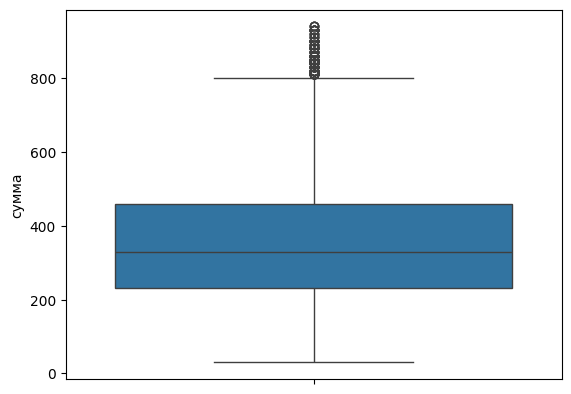

In [134]:
# далее боксплоты, кдеплоты, тесты qq и шапиро, далее в зависимости от реза ттест или непараметр, корреляция, r2
sns.boxplot(winter)

<Axes: ylabel='сумма'>

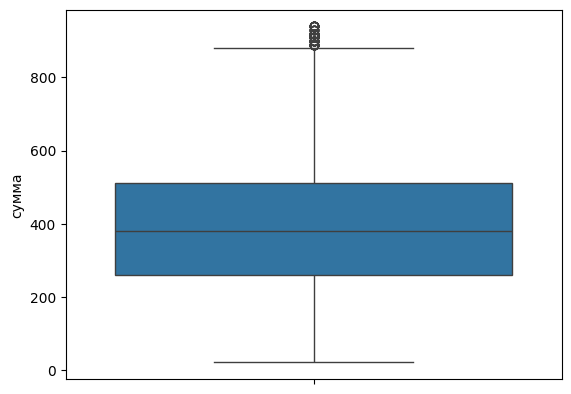

In [135]:
sns.boxplot(autumn)

Видим, что также есть выбросы

Давайте здесь уже не будем проводить тесты на нормальность, просто проведем т-тест и непараметрический тест сначала с выбросами, потом без.

In [136]:
results = st.ttest_ind(autumn, winter)
alpha = 0.05
print('Значение p-value:', results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью отличается')
else:
    print('Не отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью не отличается')

Значение p-value: 1.5314343609177508e-67
Отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью отличается


Результат другой! Очень интересно!

In [137]:
alpha = 0.05 # уровень статистической значимости

# если p-value окажется меньше него, отвергнем гипотезу

results = st.mannwhitneyu(winter, autumn)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью отличается ') 
else:
    print('Не удалось отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью не отличается') 

p-value: 3.590101570586457e-70
Следует отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью отличается 


In [138]:
winter.describe()

count    11399.000000
mean       362.613387
std        166.273749
min         30.000000
25%        230.000000
50%        330.000000
75%        460.000000
max        940.000000
Name: сумма, dtype: float64

In [139]:
# Зачистим выбросы
vybros = winter.describe()['75%'] + 1.5 * (winter.describe()['75%'] - winter.describe()['25%'])
vybros


np.float64(805.0)

In [140]:
winter = winter.reset_index()
winter = winter[winter['сумма'] < 805].reset_index(drop=True)


In [141]:
autumn.describe()

count    12327.000000
mean       401.461021
std        176.417692
min         20.000000
25%        260.000000
50%        380.000000
75%        510.000000
max        940.000000
Name: сумма, dtype: float64

In [142]:
vybros = autumn.describe()['75%'] + 1.5 * (autumn.describe()['75%'] - autumn.describe()['25%'])
vybros


np.float64(885.0)

In [143]:
autumn = autumn.reset_index()
autumn = autumn[autumn['сумма'] < 885].reset_index(drop=True)


In [144]:
autumn = np.array(autumn['сумма'])
winter = np.array(winter['сумма'])

In [145]:
results = st.ttest_ind(autumn, winter)
alpha = 0.05
print('Значение p-value:', results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью отличается')
else:
    print('Не отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью не отличается')

Значение p-value: 1.253558265750779e-86
Отвергаем нулевую гипотезу: средняя выручка от продажи билетов зимой и осенью отличается


In [146]:
alpha = 0.05 # уровень статистической значимости

# если p-value окажется меньше него, отвергнем гипотезу

results = st.mannwhitneyu(winter, autumn)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью отличается ') 
else:
    print('Не удалось отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью не отличается') 

p-value: 1.8808021074899717e-80
Следует отвергнуть нулевую гипотезу: Выручка от продаж зимой и осенью отличается 


Все равно результат отличается!


In [147]:
kf = df.groupby('название месяца', as_index=False).agg(количество=('сумма', 'count'), выручка=('сумма', 'sum'))
kf

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\3172135287.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kf = df.groupby('название месяца', as_index=False).agg(количество=('сумма', 'count'), выручка=('сумма', 'sum'))


,название месяца,количество,выручка
0,November,4511,1592670
1,December,4110,1507430
2,January,5059,1815020
3,February,2230,810980
4,March,3599,1286650
5,April,4133,1961450
6,May,2420,1091790
7,June,3499,1605260
8,July,4463,2158020
9,August,6538,3227310


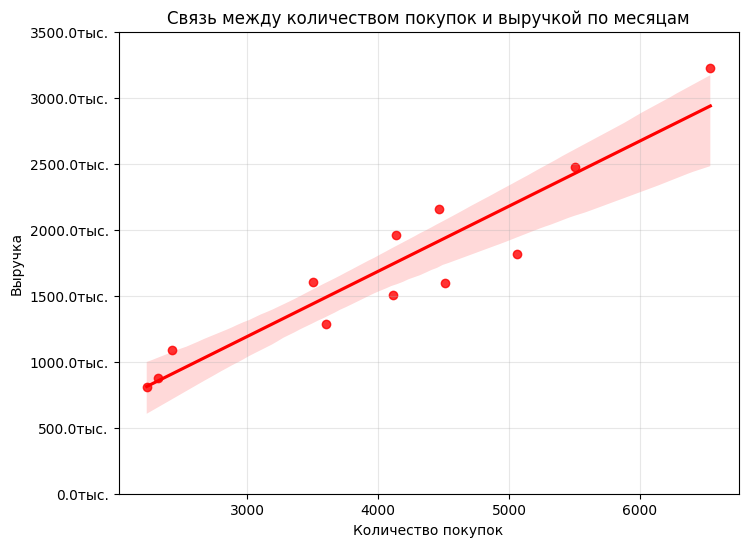

In [148]:
plt.figure(figsize=(8,6))
sns.regplot(kf, x='количество', y='выручка', color='red')
plt.xlabel('Количество покупок')
plt.ylabel('Выручка')
current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f'{t/1000}тыс.' for t in current_ticks])
plt.title('Связь между количеством покупок и выручкой по месяцам')
plt.grid(True, alpha=0.3)
plt.show()

In [149]:
kf[['количество', 'выручка']].corr()

,количество,выручка
количество,1.000000,0.939463
выручка,0.939463,1.000000


In [150]:
print('Корреляция методом Спирмена:', kf[['количество', 'выручка']].corr(method='spearman'))
print('Корреляция методом Кендалла:', kf[['количество', 'выручка']].corr(method='kendall'))


Корреляция методом Спирмена:             количество   выручка
количество    1.000000  0.888112
выручка       0.888112  1.000000
Корреляция методом Кендалла:             количество   выручка
количество    1.000000  0.787879
выручка       0.787879  1.000000



Я прочитал, что с точки зрения финансовой отчетности выручка признаётся только по дате совершения перелета, а не по дате покупки билета. Это международный стандарт - правило признания выручки после выполнения обязательства. То есть когда пассажир купил билет, в этот момент компания еще ничего не сделала, она только получила деньги. 

НО! С точки зрения операционного учета (операционной аналитики), можно считать по дате покупки билета. Только это уже будет называться не выручкой, а просто продажами. Так что, оба теста имеют место быть.

Вывод по корреляции: Корреляция по месяцу покупки (0,78) показывает сильную, но менее устойчивую связь, тогда как корреляция по месяцу полёта (0,94) демонстрирует почти идеальную зависимость. Это означает, что объёмы фактически совершённых перелётов гораздо точнее объясняют динамику выручки, чем количество покупок, показанное по датам приобретения.






3.4 Клиенты покупают билеты в разное время. Кто-то покупает билеты заранее, другие - в последний момент. Проверьте гипотезу о том, что выручка от продажи билетов для этих двух групп клиентов отличается. Предварительно разбейте клиентов минимум на три группы.

In [151]:
df['разница'] = df['дата совершения перелета'] - df['дата покупки']
df.head()

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\3547878053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['разница'] = df['дата совершения перелета'] - df['дата покупки']


,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал,сезон,разница
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,нет,ONLINE,2022,January,1,1,1,зима,35 days
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,нет,OFFLINE,2022,January,1,0,1,зима,3 days
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,есть,ONLINE,2022,January,1,1,1,зима,37 days
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,нет,ONLINE,2022,January,1,2,1,зима,28 days
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,есть,OFFLINE,2022,January,1,2,1,зима,35 days


In [152]:
df['группа'] = pd.cut(df['разница'].dt.days, bins = [0, 4, 24, 9999], labels = ['поздно', 'средне', 'заранее'], right=True)
df

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\3222490208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['группа'] = pd.cut(df['разница'].dt.days, bins = [0, 4, 24, 9999], labels = ['поздно', 'средне', 'заранее'], right=True)


,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал,сезон,разница,группа
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,нет,ONLINE,2022,January,1,1,1,зима,35 days,заранее
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,нет,OFFLINE,2022,January,1,0,1,зима,3 days,поздно
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,есть,ONLINE,2022,January,1,1,1,зима,37 days,заранее
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,нет,ONLINE,2022,January,1,2,1,зима,28 days,заранее
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,есть,OFFLINE,2022,January,1,2,1,зима,35 days,заранее
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49360,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,нет,ONLINE,2022,June,6,2,2,лето,11 days,средне
49361,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,нет,OFFLINE,2022,June,6,0,2,лето,14 days,средне
49362,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,есть,ONLINE,2022,June,6,2,2,лето,3 days,поздно
49363,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,нет,OFFLINE,2022,June,6,1,2,лето,2 days,поздно


In [153]:
table16 = df.groupby('группа')['сумма'].sum().reset_index()
table16

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\907150770.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table16 = df.groupby('группа')['сумма'].sum().reset_index()


,группа,сумма
0,поздно,5621090
1,средне,8970440
2,заранее,5327540


<Axes: xlabel='группа', ylabel='сумма'>

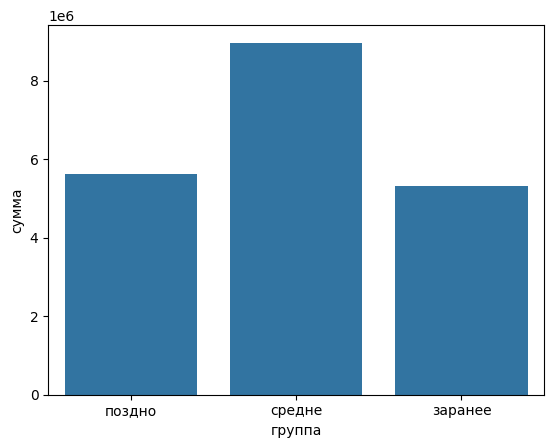

In [154]:
sns.barplot(table16, x='группа', y='сумма')

In [155]:
late = df[df['группа'] == 'поздно']['сумма']
early = df[df['группа'] == 'заранее']['сумма']
# Сначала боксплот, потом дисплот, потом два теста на нормальность

<Axes: ylabel='сумма'>

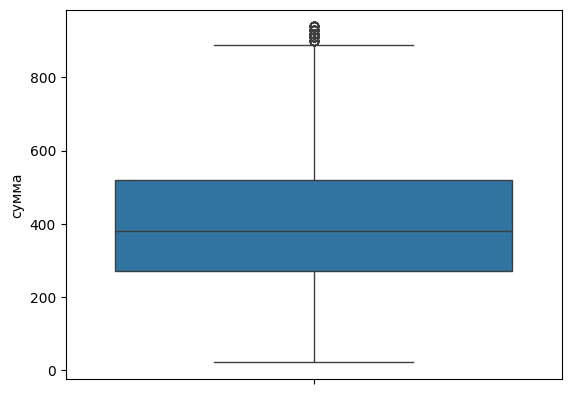

In [156]:
sns.boxplot(late)

<Axes: ylabel='сумма'>

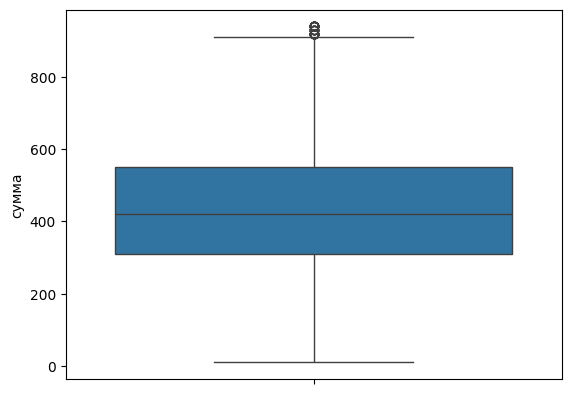

In [157]:
sns.boxplot(early)

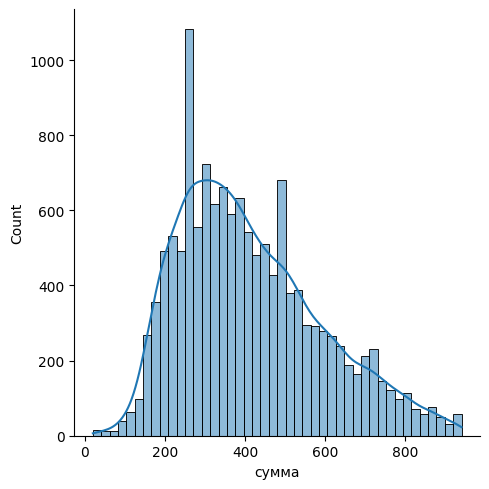

In [158]:
sns.displot(late, kde=True)

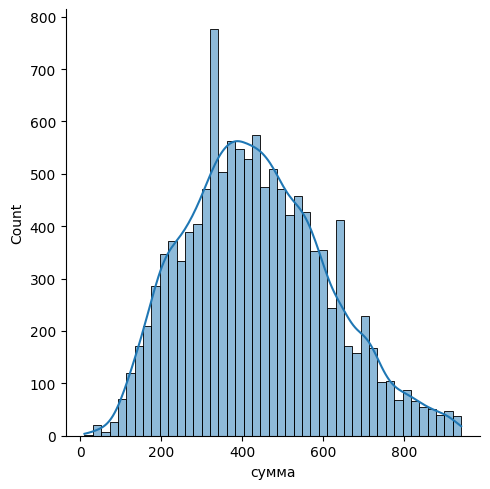

In [159]:
sns.displot(early, kde=True)

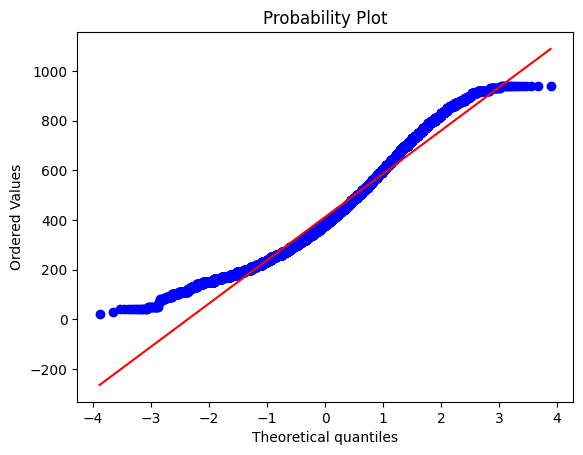

In [160]:
st.probplot(late, dist='norm', plot=plt)
plt.show()

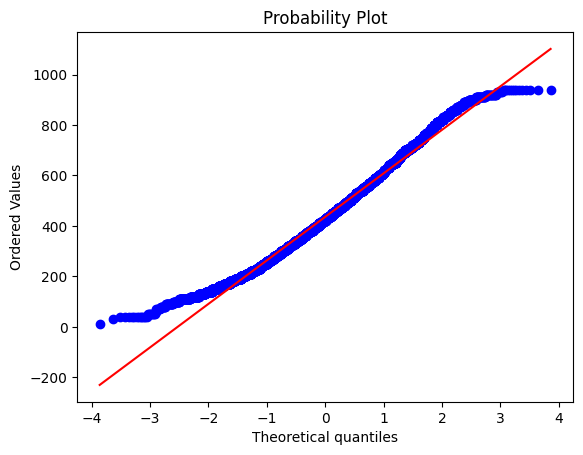

In [161]:
st.probplot(early, dist='norm', plot=plt)
plt.show()

In [162]:
stat, p = st.shapiro(late)
alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')

1.6409413847322396e-50 Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения


c:\Users\shopi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13638.
  res = hypotest_fun_out(*samples, **kwds)


In [163]:
stat, p = st.shapiro(early)
alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')

3.0157414875167486e-32 Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения


c:\Users\shopi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12229.
  res = hypotest_fun_out(*samples, **kwds)


In [164]:
alpha = 0.05 # уровень статистической значимости

# если p-value окажется меньше него, отвергнем гипотезу

results = st.mannwhitneyu(late, early)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу: Выручка от продаж билетов, купленных заранее и купленных в последний момент отличается') 
else:
    print('Не удалось отвергнуть нулевую гипотезу: Выручка от продаж билетов, купленных заранее и купленных в последний момент не отличается') 

p-value: 1.0372646461289428e-39
Следует отвергнуть нулевую гипотезу: Выручка от продаж билетов, купленных заранее и купленных в последний момент отличается


Конечно, тут все зависит от интервалов. Наверное, все-таки максимальная граница для группы "Купили билеты в последний момент" - это 4 дня, не более. Сложнее определить границу для тех, кто купил билеты заранее. Ниже сделаем границы такими: 2 дня и менее - для тех, кто купил в последний момент и 30 дней и более для тех, кто купил билеты заранее. Заново проведем тест

In [165]:
df['группа'] = pd.cut(df['разница'].dt.days, bins = [0, 2, 30, 9999], labels = ['поздно', 'средне', 'заранее'], right=True)

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\2841500075.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['группа'] = pd.cut(df['разница'].dt.days, bins = [0, 2, 30, 9999], labels = ['поздно', 'средне', 'заранее'], right=True)


In [166]:
table16 = df.groupby('группа')['сумма'].sum().reset_index()
table16

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\907150770.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table16 = df.groupby('группа')['сумма'].sum().reset_index()


,группа,сумма
0,поздно,3074230
1,средне,12576860
2,заранее,4267980


<Axes: xlabel='группа', ylabel='сумма'>

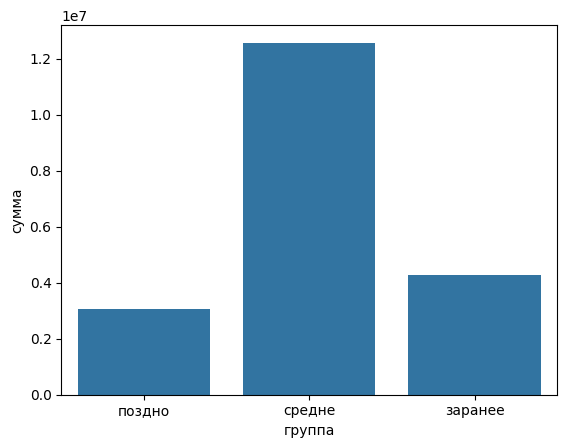

In [167]:
sns.barplot(table16, x='группа', y='сумма')



In [168]:
late = df[df['группа'] == 'поздно']['сумма']
early = df[df['группа'] == 'заранее']['сумма']

<Axes: ylabel='сумма'>

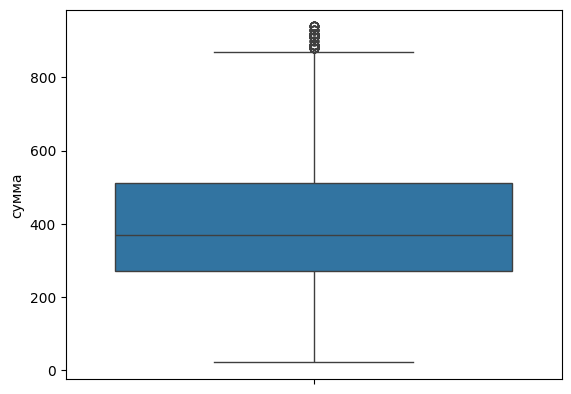

In [169]:
sns.boxplot(late)


<Axes: ylabel='сумма'>

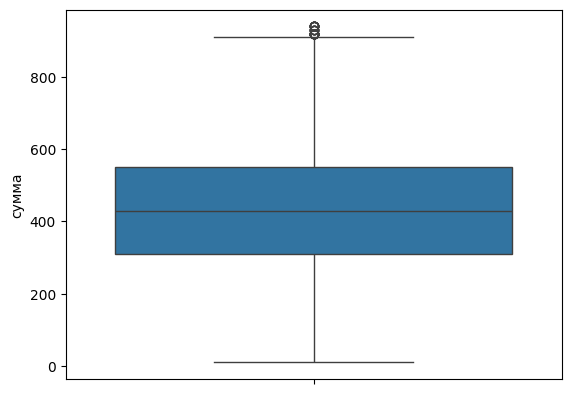

In [170]:
sns.boxplot(early)

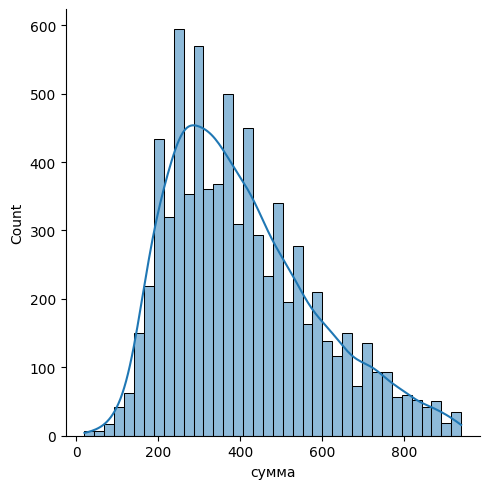

In [171]:
sns.displot(late, kde=True)

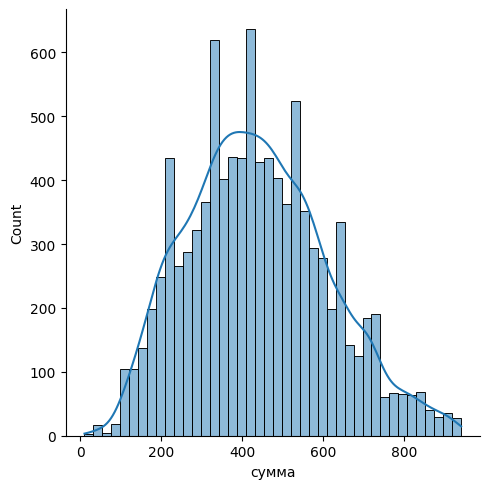

In [172]:
sns.displot(early, kde=True)

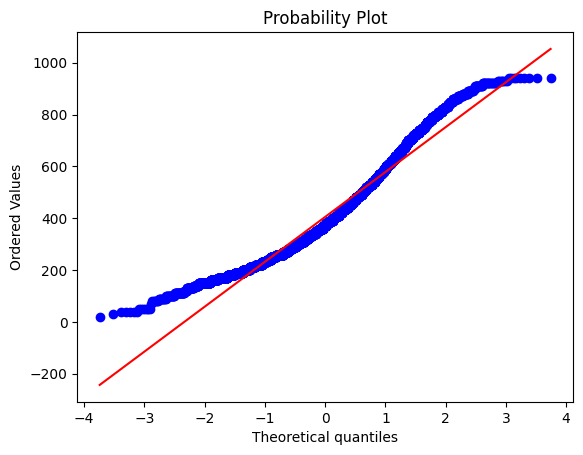

In [173]:
st.probplot(late, dist='norm', plot=plt)
plt.show()


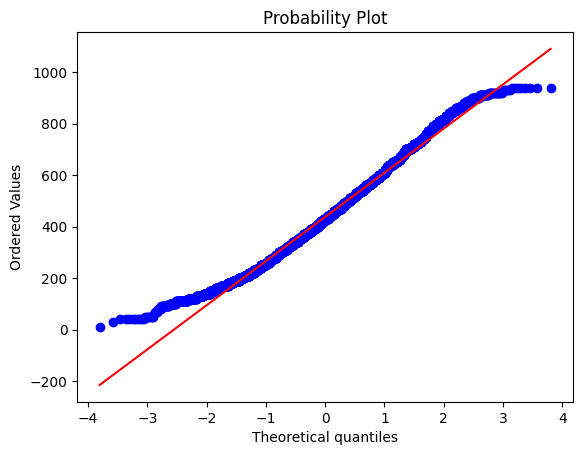

In [174]:
st.probplot(early, dist='norm', plot=plt)
plt.show()


In [175]:
stat, p = st.shapiro(late)
alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')


2.3303572732726795e-43 Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения


c:\Users\shopi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7590.
  res = hypotest_fun_out(*samples, **kwds)


In [176]:
stat, p = st.shapiro(early)
alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')


5.7354171378302125e-28 Отвергаем нулевую гипотезу. Выборка не имеет нормального распределения


c:\Users\shopi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9750.
  res = hypotest_fun_out(*samples, **kwds)


In [177]:
alpha = 0.05 # уровень статистической значимости

# если p-value окажется меньше него, отвергнем гипотезу

results = st.mannwhitneyu(late, early)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу: Выручка от продаж билетов, купленных заранее и купленных в последний момент отличается') 
else:
    print('Не удалось отвергнуть нулевую гипотезу: Выручка от продаж билетов, купленных заранее и купленных в последний момент не отличается') 

p-value: 5.978150458421807e-49
Следует отвергнуть нулевую гипотезу: Выручка от продаж билетов, купленных заранее и купленных в последний момент отличается


In [178]:
early.describe()

count    9750.000000
mean      437.741538
std       172.622091
min        10.000000
25%       310.000000
50%       430.000000
75%       550.000000
max       940.000000
Name: сумма, dtype: float64

In [179]:
late.describe()

count    7590.000000
mean      405.036891
std       177.253590
min        20.000000
25%       270.000000
50%       370.000000
75%       510.000000
max       940.000000
Name: сумма, dtype: float64

Опять отвергли гипотезу :(

Среднее значение у них действительно отличается: билеты, купленные в последний момент, выходили для пассажиров дороже. Это логично, в таких случаях авиакомпании часто завышают цену.

3 .5  Определите топ-10 популярных направлений перелета (город-город) отдельно для ВМЛ и МВЛ. Изучите выручку для этих направлений. Для этого добавьте в датасет сведения о городах, используя данные из датасета:
     https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat

In [180]:
df['направление'] = df['город назначения'] + '-' + df['город отправления']


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\2245310142.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['направление'] = df['город назначения'] + '-' + df['город отправления']


In [181]:
url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat"
data = pd.read_csv(url, header=None)


In [182]:
data.columns = ['AirportID', 'Name', 'City', 'Country', 'IATA', 'ICAO', 'Latitude', 'Longitude', 'Altitude', 'Timezone', 'DST', 'TZ', 'Type', 'Source']


In [183]:
data

,AirportID,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,TZ,Type,Source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7693,14106,Rogachyovo Air Base,Belaya,Russia,\N,ULDA,71.616699,52.478298,272,\N,\N,\N,airport,OurAirports
7694,14107,Ulan-Ude East Airport,Ulan Ude,Russia,\N,XIUW,51.849998,107.737999,1670,\N,\N,\N,airport,OurAirports
7695,14108,Krechevitsy Air Base,Novgorod,Russia,\N,ULLK,58.625000,31.385000,85,\N,\N,\N,airport,OurAirports
7696,14109,Desierto de Atacama Airport,Copiapo,Chile,CPO,SCAT,-27.261200,-70.779198,670,\N,\N,\N,airport,OurAirports


In [184]:
data[data['IATA'] == '\\N']

,AirportID,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,TZ,Type,Source
21,22,Winnipeg / St. Andrews Airport,Winnipeg,Canada,\N,CYAV,50.056400,-97.032501,760,-6,A,America/Winnipeg,airport,OurAirports
22,23,Halifax / CFB Shearwater Heliport,Halifax,Canada,\N,CYAW,44.639702,-63.499401,144,-4,A,America/Halifax,airport,OurAirports
43,44,Princeton Airport,Princeton,Canada,\N,CYDC,49.468102,-120.511002,2298,-8,A,America/Vancouver,airport,OurAirports
103,104,Pitt Meadows Airport,Pitt Meadows,Canada,\N,CYPK,49.216099,-122.709999,11,-8,A,America/Vancouver,airport,OurAirports
210,212,Boufarik Airport,Boufarik,Algeria,\N,DAAK,36.545799,2.876110,335,1,N,Africa/Algiers,airport,OurAirports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7692,14105,Kubinka Air Base,Kubinka,Russia,\N,UUMB,55.611695,36.650002,614,\N,\N,\N,airport,OurAirports
7693,14106,Rogachyovo Air Base,Belaya,Russia,\N,ULDA,71.616699,52.478298,272,\N,\N,\N,airport,OurAirports
7694,14107,Ulan-Ude East Airport,Ulan Ude,Russia,\N,XIUW,51.849998,107.737999,1670,\N,\N,\N,airport,OurAirports
7695,14108,Krechevitsy Air Base,Novgorod,Russia,\N,ULLK,58.625000,31.385000,85,\N,\N,\N,airport,OurAirports


In [185]:
city = data.set_index("IATA")['City'].to_dict()
city

{'GKA': 'Goroka',
 'MAG': 'Madang',
 'HGU': 'Mount Hagen',
 'LAE': 'Nadzab',
 'POM': 'Port Moresby',
 'WWK': 'Wewak',
 'UAK': 'Narssarssuaq',
 'GOH': 'Godthaab',
 'SFJ': 'Sondrestrom',
 'THU': 'Thule',
 'AEY': 'Akureyri',
 'EGS': 'Egilsstadir',
 'HFN': 'Hofn',
 'HZK': 'Husavik',
 'IFJ': 'Isafjordur',
 'KEF': 'Keflavik',
 'PFJ': 'Patreksfjordur',
 'RKV': 'Reykjavik',
 'SIJ': 'Siglufjordur',
 'VEY': 'Vestmannaeyjar',
 'YAM': 'Sault Sainte Marie',
 '\\N': 'Melitopol',
 'YAY': 'St. Anthony',
 'YAZ': 'Tofino',
 'YBB': 'Pelly Bay',
 'YBC': 'Baie Comeau',
 'YBG': 'Bagotville',
 'YBK': 'Baker Lake',
 'YBL': 'Campbell River',
 'YBR': 'Brandon',
 'YCB': 'Cambridge Bay',
 'YCD': 'Nanaimo',
 'YCG': 'Castlegar',
 'YCH': 'Chatham',
 'YCL': 'Charlo',
 'YCO': 'Coppermine',
 'YCT': 'Coronation',
 'YCW': 'Chilliwack',
 'YCY': 'Clyde River',
 'YZS': 'Coral Harbour',
 'YDA': 'Dawson',
 'YDB': 'Burwash',
 'YDF': 'Deer Lake',
 'YDL': 'Dease Lake',
 'YDN': 'Dauphin',
 'YDQ': 'Dawson Creek',
 'YEG': 'Edmonton

In [186]:
df['город_отпр_название'] = df['город отправления'].map(city)
df['город_назнач_название'] = df['город назначения'].map(city)
df

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1098047417.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['город_отпр_название'] = df['город отправления'].map(city)
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1098047417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['город_назнач_название'] = df['город назначения'].map(city)


,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал,сезон,разница,группа,направление,город_отпр_название,город_назнач_название
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,нет,ONLINE,2022,January,1,1,1,зима,35 days,заранее,KGD-MOW,NaN,Kaliningrad
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,нет,OFFLINE,2022,January,1,0,1,зима,3 days,средне,OVB-UUS,Yuzhno-sakhalinsk,Novosibirsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,есть,ONLINE,2022,January,1,1,1,зима,37 days,заранее,MOW-KGD,Kaliningrad,NaN
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,нет,ONLINE,2022,January,1,2,1,зима,28 days,средне,MOW-VOZ,Voronezh,NaN
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,есть,OFFLINE,2022,January,1,2,1,зима,35 days,заранее,KRR-MOW,NaN,Krasnodar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49360,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,нет,ONLINE,2022,June,6,2,2,лето,11 days,средне,OMS-MOW,NaN,Omsk
49361,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,нет,OFFLINE,2022,June,6,0,2,лето,14 days,средне,MOW-LED,St. Petersburg,NaN
49362,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,есть,ONLINE,2022,June,6,2,2,лето,3 days,средне,KZN-MOW,NaN,Kazan
49363,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,нет,OFFLINE,2022,June,6,1,2,лето,2 days,поздно,MOW-KZN,Kazan,NaN


In [187]:
nan1 = df[df['город_отпр_название'].isna()]['город отправления'].unique() 
nan1

array(['MOW', 'PAR', 'BAK', 'ROM', 'SEL', 'BER', 'GRV', 'неизвестно',
       'NQZ', 'OHH', 'TOX', 'MIL', 'TYO', 'LON'], dtype=object)

In [188]:
nan2 = df[df['город_назнач_название'].isna()]['город назначения'].unique() 
nan2

array(['MOW', 'BAK', 'GRV', 'BER', 'TOX', 'NQZ', 'ROM', 'SEL', 'PAR',
       'LON', 'TYO', 'MIL', 'неизвестно'], dtype=object)

In [189]:
all_nan = sorted(set(nan1) | set(nan2))
all_nan

['BAK',
 'BER',
 'GRV',
 'LON',
 'MIL',
 'MOW',
 'NQZ',
 'OHH',
 'PAR',
 'ROM',
 'SEL',
 'TOX',
 'TYO',
 'неизвестно']

In [190]:
data1 = {'BAK': 'Baku', 'BER': 'Berlin', 'GRV': 'Grozny', 'LON': 'London', 'MIL': 'Milan', 'MOW': 'Moscow', 'NQZ': 'Astana', 'PAR': 'Paris', 'ROM': 'Rome', 'SEL': 'Seoul', 'TOX': 'Tobolsk', 'TYO': 'Tokyo', 'неизвестно': 'неизвестно'}


In [191]:
full_dictionary = city.copy()
full_dictionary.update(data1)

In [192]:
df['город_отпр_название'] = df['город отправления'].map(full_dictionary)
df['город_назнач_название'] = df['город назначения'].map(full_dictionary)
df

C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1738935053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['город_отпр_название'] = df['город отправления'].map(full_dictionary)
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\1738935053.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['город_назнач_название'] = df['город назначения'].map(full_dictionary)


,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал,сезон,разница,группа,направление,город_отпр_название,город_назнач_название
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,нет,ONLINE,2022,January,1,1,1,зима,35 days,заранее,KGD-MOW,Moscow,Kaliningrad
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,нет,OFFLINE,2022,January,1,0,1,зима,3 days,средне,OVB-UUS,Yuzhno-sakhalinsk,Novosibirsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,есть,ONLINE,2022,January,1,1,1,зима,37 days,заранее,MOW-KGD,Kaliningrad,Moscow
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,нет,ONLINE,2022,January,1,2,1,зима,28 days,средне,MOW-VOZ,Voronezh,Moscow
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,есть,OFFLINE,2022,January,1,2,1,зима,35 days,заранее,KRR-MOW,Moscow,Krasnodar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49360,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,нет,ONLINE,2022,June,6,2,2,лето,11 days,средне,OMS-MOW,Moscow,Omsk
49361,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,нет,OFFLINE,2022,June,6,0,2,лето,14 days,средне,MOW-LED,St. Petersburg,Moscow
49362,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,есть,ONLINE,2022,June,6,2,2,лето,3 days,средне,KZN-MOW,Moscow,Kazan
49363,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,нет,OFFLINE,2022,June,6,1,2,лето,2 days,поздно,MOW-KZN,Kazan,Moscow


In [193]:
df['город_отпр_название'].unique()

array(['Moscow', 'Yuzhno-sakhalinsk', 'Kaliningrad', 'Voronezh',
       'Novosibirsk', 'Kazan', 'Ulan-ude', 'Tashkent', 'Yekaterinburg',
       'Omsk', 'St. Petersburg', 'Beslan', 'Sochi', 'Belgorod',
       'Krasnodar', 'Kemorovo', 'Samara', 'Khudzhand', 'Novy Urengoy',
       'Irkutsk', 'Bourgas', 'Dubai', 'Krasnoyarsk', 'Anapa', 'Tomsk',
       'Lipetsk', 'Surgut', 'Antalya', 'Hurghada', 'Ufa', 'Varna',
       'Mirnyj', 'Gelendzhik', 'Simferopol', 'Rostov', 'Murmansk',
       'Chisinau', 'Paris', 'Bratsk', 'Apatity', 'Perm', 'Saratov',
       'Neryungri', 'Novokuznetsk', 'Makhachkala', 'Nizhniy Novgorod',
       'Nizhnevartovsk', 'Magnetiogorsk', 'Sharm El Sheikh', 'Yakutsk',
       'Blagoveschensk', 'Ivanovo', 'Vladivostok', 'Petropavlovsk',
       'Abakan', 'Noyabrsk', 'Chelyabinsk', 'Penza', 'Baku', 'Volgograd',
       'Ulyanovsk', 'Talakan', 'Norilsk', 'Khanabad', 'Kurgan Tyube',
       'Munich', 'Fergana', 'Rome', 'Alma-ata', 'Mineralnye Vody',
       'Chita', 'Urgench', 'Stavr

In [194]:
df['город_назнач_название'].unique()

array(['Kaliningrad', 'Novosibirsk', 'Moscow', 'Krasnodar', 'Duesseldorf',
       'Perm', 'Sochi', 'Nizhnevartovsk', 'Samara', 'Ulan-ude',
       'Helsinki', 'St. Petersburg', 'Abakan', 'Yerevan', 'Gelendzhik',
       'Kazan', 'Mineralnye Vody', 'Simferopol', 'Thessaloniki',
       'Fergana', 'Magnetiogorsk', 'Volgograd', 'Phuket', 'Chelyabinsk',
       'Saratov', 'Irkutsk', 'Ulyanovsk', 'Novy Urengoy', 'Tomsk',
       'Dubai', 'Yakutsk', 'Yuzhno-sakhalinsk', 'Blagoveschensk',
       'Yekaterinburg', 'Petropavlovsk', 'Surgut', 'Izhevsk', 'Beslan',
       'Anapa', 'Murmansk', 'Krasnoyarsk', 'Chisinau', 'Novokuznetsk',
       'Baku', 'Ufa', 'Cologne', 'Rostov', 'Neryungri', 'Belgorod',
       'Kemorovo', 'Talakan', 'Vienna', 'Barnaul', 'Penza', 'Chita',
       'Stavropol', 'Magadan', 'Vladivostok', 'Antalya', 'Gorno-Altaysk',
       'Villafranca', 'Tashkent', 'Bologna', 'Bratsk', 'Norilsk', 'Osh',
       'Nizhniy Novgorod', 'Astrakhan', 'Sharm El Sheikh', 'Dushanbe',
       'Omsk', 'Voro

In [195]:
df[df['город_отпр_название'].isna()]

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал,сезон,разница,группа,направление,город_отпр_название,город_назнач_название
6837,2021-12-27,2022-01-19,AD,320,OHH,KHV,ВВЛ,нет,OFFLINE,2022,January,1,2,1,зима,23 days,средне,KHV-OHH,NaN,Khabarovsk


In [196]:
df[df['город отправления'] == 'OHH']

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал,сезон,разница,группа,направление,город_отпр_название,город_назнач_название
6837,2021-12-27,2022-01-19,AD,320,OHH,KHV,ВВЛ,нет,OFFLINE,2022,January,1,2,1,зима,23 days,средне,KHV-OHH,NaN,Khabarovsk


In [197]:
df = df[df['город отправления'] != 'OHH']


In [198]:
df[df['город отправления'] == 'неизвестно']

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал,сезон,разница,группа,направление,город_отпр_название,город_назнач_название
1995,2022-02-17,2022-03-22,AD,440,неизвестно,KHV,МВЛ,нет,ONLINE,2022,March,3,1,1,весна,33 days,заранее,KHV-неизвестно,неизвестно,Khabarovsk
8005,2022-05-02,2022-05-11,AD,440,неизвестно,KHV,МВЛ,нет,OFFLINE,2022,May,5,2,2,весна,9 days,средне,KHV-неизвестно,неизвестно,Khabarovsk


In [199]:
df = df[df['город отправления'] != 'неизвестно']
df

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,название месяца,месяц,день недели,квартал,сезон,разница,группа,направление,город_отпр_название,город_назнач_название
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,нет,ONLINE,2022,January,1,1,1,зима,35 days,заранее,KGD-MOW,Moscow,Kaliningrad
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,нет,OFFLINE,2022,January,1,0,1,зима,3 days,средне,OVB-UUS,Yuzhno-sakhalinsk,Novosibirsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,есть,ONLINE,2022,January,1,1,1,зима,37 days,заранее,MOW-KGD,Kaliningrad,Moscow
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,нет,ONLINE,2022,January,1,2,1,зима,28 days,средне,MOW-VOZ,Voronezh,Moscow
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,есть,OFFLINE,2022,January,1,2,1,зима,35 days,заранее,KRR-MOW,Moscow,Krasnodar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49360,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,нет,ONLINE,2022,June,6,2,2,лето,11 days,средне,OMS-MOW,Moscow,Omsk
49361,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,нет,OFFLINE,2022,June,6,0,2,лето,14 days,средне,MOW-LED,St. Petersburg,Moscow
49362,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,есть,ONLINE,2022,June,6,2,2,лето,3 days,средне,KZN-MOW,Moscow,Kazan
49363,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,нет,OFFLINE,2022,June,6,1,2,лето,2 days,поздно,MOW-KZN,Kazan,Moscow


In [200]:
df['город-город'] = df['город_отпр_название'] + '-' + df['город_назнач_название']
df['город-город'].value_counts()

город-город
Sochi-Moscow             1326
Moscow-Sochi             1292
St. Petersburg-Moscow    1211
Moscow-St. Petersburg    1190
Novosibirsk-Moscow        967
                         ... 
Khabarovsk-Nogliki          1
Casablanca-Moscow           1
Dalaman-Moscow              1
Osh-Omsk                    1
Ulan-ude-Khabarovsk         1
Name: count, Length: 634, dtype: int64

In [201]:
pivot_city = df.pivot_table(index=['город-город', 'тип перелета'], aggfunc={'сумма': ['count', 'sum']}).reset_index()
pivot_city.columns = ['город-город', 'тип перелета', 'количество', 'сумма']
pivot_city

,город-город,тип перелета,количество,сумма
0,Abakan-Krasnoyarsk,ВВЛ,6,1080
1,Abakan-Moscow,ВВЛ,139,73220
2,Abakan-Novosibirsk,ВВЛ,125,43490
3,Alicante-Moscow,МВЛ,16,7270
4,Alma-ata-Moscow,МВЛ,7,3610
...,...,...,...,...
629,Yuzhno-sakhalinsk-Krasnoyarsk,ВВЛ,6,2570
630,Yuzhno-sakhalinsk-Novosibirsk,ВВЛ,139,92780
631,Yuzhno-sakhalinsk-Petropavlovsk,ВВЛ,3,950
632,Yuzhno-sakhalinsk-Vladivostok,ВВЛ,132,50130


In [202]:
top_M = pivot_city[pivot_city['тип перелета'] == 'МВЛ'].sort_values(by='количество', ascending=False).head(10)
top_M

,город-город,тип перелета,количество,сумма
298,Moscow-Osh,МВЛ,151,68130
168,Khudzhand-Moscow,МВЛ,144,95190
460,Osh-Moscow,МВЛ,136,80920
269,Moscow-Khudzhand,МВЛ,129,57710
372,Novosibirsk-Bishkek,МВЛ,120,46980
414,Novosibirsk-Osh,МВЛ,119,47450
170,Khudzhand-Novosibirsk,МВЛ,116,57740
462,Osh-Novosibirsk,МВЛ,115,56980
42,Bishkek-Novosibirsk,МВЛ,102,48300
231,Moscow-Antalya,МВЛ,101,38080


In [203]:
top_B = pivot_city[pivot_city['тип перелета'] == 'ВВЛ'].sort_values(by='количество', ascending=False).head(10)
top_B

,город-город,тип перелета,количество,сумма
521,Sochi-Moscow,ВВЛ,1326,513970
314,Moscow-Sochi,ВВЛ,1292,480480
530,St. Petersburg-Moscow,ВВЛ,1211,280870
315,Moscow-St. Petersburg,ВВЛ,1190,273720
401,Novosibirsk-Moscow,ВВЛ,967,460720
293,Moscow-Novosibirsk,ВВЛ,944,440440
142,Kazan-Moscow,ВВЛ,759,205230
265,Moscow-Kazan,ВВЛ,757,204660
323,Moscow-Ufa,ВВЛ,708,210610
424,Novosibirsk-Sochi,ВВЛ,668,382470


C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\3228883048.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top_M, x='город-город', y='сумма', ax=axes[0], palette='cool')
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\3228883048.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=60)
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\3228883048.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top_B, x='город-город', y='сумма', ax=axes[1], palette='Greens')
C:\Users\shopi\AppData\Local\Temp\ipykernel_2716\3228883048.py:11: UserWarning: set_ti

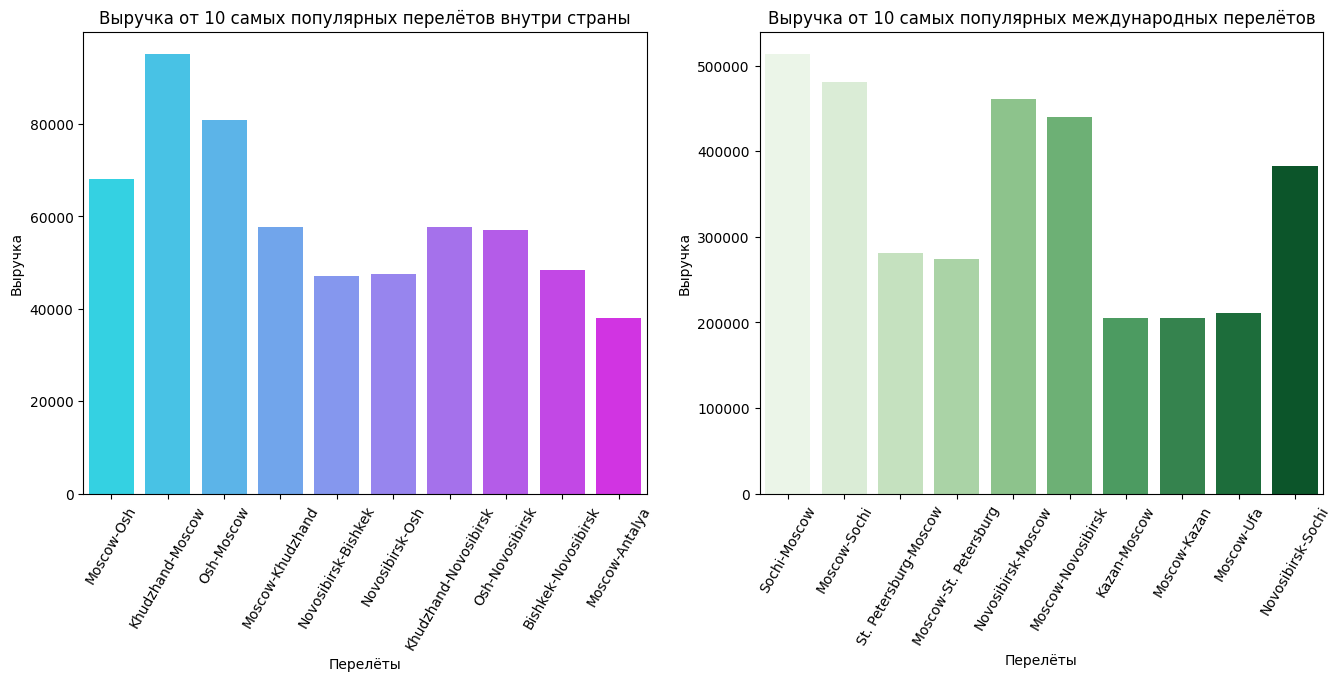

In [204]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(top_M, x='город-город', y='сумма', ax=axes[0], palette='cool')
axes[0].set_ylabel('Выручка')
axes[0].set_xlabel('Перелёты')
axes[0].set_title('Выручка от 10 самых популярных перелётов внутри страны')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=60)
sns.barplot(top_B, x='город-город', y='сумма', ax=axes[1], palette='Greens')
axes[1].set_ylabel('Выручка')
axes[1].set_xlabel('Перелёты')
axes[1].set_title('Выручка от 10 самых популярных международных перелётов')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=60)
plt.show()


In [205]:
df[df['город-город'] == "Khudzhand-Moscow"]

,дата покупки,дата совершения перелета,тип пассажиров,сумма,город отправления,город назначения,тип перелета,наличие программы лояльности,способ покупки,год,...,месяц,день недели,квартал,сезон,разница,группа,направление,город_отпр_название,город_назнач_название,город-город
894,2021-10-09,2021-11-03,AD,700,LBD,MOW,МВЛ,есть,OFFLINE,2021,...,11,2,4,осень,25 days,средне,MOW-LBD,Khudzhand,Moscow,Khudzhand-Moscow
1105,2021-11-28,2022-01-29,AD,530,LBD,MOW,МВЛ,нет,ONLINE,2022,...,1,5,1,зима,62 days,заранее,MOW-LBD,Khudzhand,Moscow,Khudzhand-Moscow
1762,2022-04-28,2022-08-01,CHD,490,LBD,MOW,МВЛ,нет,OFFLINE,2022,...,8,0,3,лето,95 days,заранее,MOW-LBD,Khudzhand,Moscow,Khudzhand-Moscow
2433,2021-12-15,2022-01-29,AD,480,LBD,MOW,МВЛ,есть,ONLINE,2022,...,1,5,1,зима,45 days,заранее,MOW-LBD,Khudzhand,Moscow,Khudzhand-Moscow
2837,2022-05-19,2022-08-07,AD,670,LBD,MOW,МВЛ,нет,ONLINE,2022,...,8,6,3,лето,80 days,заранее,MOW-LBD,Khudzhand,Moscow,Khudzhand-Moscow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47959,2021-10-21,2021-10-24,CHD,800,LBD,MOW,МВЛ,нет,OFFLINE,2021,...,10,6,4,осень,3 days,средне,MOW-LBD,Khudzhand,Moscow,Khudzhand-Moscow
48225,2022-07-12,2022-07-14,AD,740,LBD,MOW,МВЛ,нет,OFFLINE,2022,...,7,3,3,лето,2 days,поздно,MOW-LBD,Khudzhand,Moscow,Khudzhand-Moscow
49075,2022-05-01,2022-05-13,AD,600,LBD,MOW,МВЛ,нет,ONLINE,2022,...,5,4,2,весна,12 days,средне,MOW-LBD,Khudzhand,Moscow,Khudzhand-Moscow
49077,2022-05-06,2022-05-27,AD,710,LBD,MOW,МВЛ,нет,OFFLINE,2022,...,5,4,2,весна,21 days,средне,MOW-LBD,Khudzhand,Moscow,Khudzhand-Moscow


Видим, что из 10 самых популярных международных направлений у нас только азиатские страны, в основном Кыргызстан, Таджикистан и Узбекистан, есть еще Турция. Сама по себе выручка от этих перелетов относительно небольшая. Причина в том, что эти маршруты в основном представлены миграционными потоками с низким средним тарифом. 
Внутренние перелёты, напротив, приносят существенную выручку, за счет высокого среднего тарифа. Скорее всего, это связано с туризмом и деловыми поездками. 
Таким образом, популярность направления по количеству перелётов не гарантирует высокой выручки.

- 3.6 Определите есть ли зависимость выручки от других признаков. Постройте матрицу корреляций.

In [206]:
# corr() работает только с числовыми значениями, поэтому создадим датасет только из таких значений

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48375 entries, 0 to 49364
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype          
---  ------                        --------------  -----          
 0   дата покупки                  48375 non-null  datetime64[ns] 
 1   дата совершения перелета      48375 non-null  datetime64[ns] 
 2   тип пассажиров                48375 non-null  object         
 3   сумма                         48375 non-null  int64          
 4   город отправления             48375 non-null  object         
 5   город назначения              48375 non-null  object         
 6   тип перелета                  48375 non-null  object         
 7   наличие программы лояльности  48375 non-null  object         
 8   способ покупки                48375 non-null  object         
 9   год                           48375 non-null  int32          
 10  название месяца               48375 non-null  category       
 11  месяц               

In [208]:
df = pd.get_dummies(df, columns=['тип перелета'])
df = pd.get_dummies(df, columns=['наличие программы лояльности'])
df = pd.get_dummies(df, columns=['способ покупки'])
df = pd.get_dummies(df, columns=['тип пассажиров'], drop_first=True)


In [209]:
df

,дата покупки,дата совершения перелета,сумма,город отправления,город назначения,год,название месяца,месяц,день недели,квартал,...,город_назнач_название,город-город,тип перелета_ВВЛ,тип перелета_МВЛ,наличие программы лояльности_есть,наличие программы лояльности_нет,способ покупки_OFFLINE,способ покупки_ONLINE,тип пассажиров_CHD,тип пассажиров_INF
0,2021-12-07,2022-01-11,200,MOW,KGD,2022,January,1,1,1,...,Kaliningrad,Moscow-Kaliningrad,True,False,False,True,False,True,False,False
1,2021-12-31,2022-01-03,610,UUS,OVB,2022,January,1,0,1,...,Novosibirsk,Yuzhno-sakhalinsk-Novosibirsk,True,False,False,True,True,False,False,False
2,2021-11-28,2022-01-04,390,KGD,MOW,2022,January,1,1,1,...,Moscow,Kaliningrad-Moscow,True,False,True,False,False,True,False,False
3,2021-12-08,2022-01-05,190,VOZ,MOW,2022,January,1,2,1,...,Moscow,Voronezh-Moscow,True,False,False,True,False,True,False,False
4,2021-12-08,2022-01-12,190,MOW,KRR,2022,January,1,2,1,...,Krasnodar,Moscow-Krasnodar,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49360,2022-06-11,2022-06-22,480,MOW,OMS,2022,June,6,2,2,...,Omsk,Moscow-Omsk,True,False,False,True,False,True,True,False
49361,2022-06-06,2022-06-20,270,LED,MOW,2022,June,6,0,2,...,Moscow,St. Petersburg-Moscow,True,False,False,True,True,False,False,False
49362,2022-06-26,2022-06-29,230,MOW,KZN,2022,June,6,2,2,...,Kazan,Moscow-Kazan,True,False,True,False,False,True,False,False
49363,2022-06-26,2022-06-28,270,KZN,MOW,2022,June,6,1,2,...,Moscow,Kazan-Moscow,True,False,False,True,True,False,False,False


In [210]:
df['дата покупки корр'] = df['дата покупки'].astype('int64')
df['дата совершения перелета корр'] = df['дата совершения перелета'].astype('int64')

In [211]:
corr_colum = ['дата покупки корр', 'дата совершения перелета корр','тип перелета_ВВЛ','способ покупки_OFFLINE','наличие программы лояльности_есть','сумма','день недели','месяц', 'год', 'квартал', 'тип пассажиров_CHD']
# помним, что в столбцах с бинарными переменными для матрицы корреляций берем только одну категорию из двух

In [212]:
data_corr = df[corr_colum]
data_corr

,дата покупки корр,дата совершения перелета корр,тип перелета_ВВЛ,способ покупки_OFFLINE,наличие программы лояльности_есть,сумма,день недели,месяц,год,квартал,тип пассажиров_CHD
0,1638835200000000000,1641859200000000000,True,False,False,200,1,1,2022,1,False
1,1640908800000000000,1641168000000000000,True,True,False,610,0,1,2022,1,False
2,1638057600000000000,1641254400000000000,True,False,True,390,1,1,2022,1,False
3,1638921600000000000,1641340800000000000,True,False,False,190,2,1,2022,1,False
4,1638921600000000000,1641945600000000000,True,True,True,190,2,1,2022,1,False
...,...,...,...,...,...,...,...,...,...,...,...
49360,1654905600000000000,1655856000000000000,True,False,False,480,2,6,2022,2,True
49361,1654473600000000000,1655683200000000000,True,True,False,270,0,6,2022,2,False
49362,1656201600000000000,1656460800000000000,True,False,True,230,2,6,2022,2,False
49363,1656201600000000000,1656374400000000000,True,True,False,270,1,6,2022,2,False


In [213]:
correlations = data_corr.corr()['сумма'].sort_values(ascending=False)
correlations = pd.DataFrame(correlations)
correlations

,сумма
сумма,1.000000
дата совершения перелета корр,0.273638
дата покупки корр,0.262307
год,0.182607
способ покупки_OFFLINE,0.166099
квартал,0.033513
месяц,0.023076
день недели,0.013577
наличие программы лояльности_есть,-0.052264
тип пассажиров_CHD,-0.062946


<Axes: >

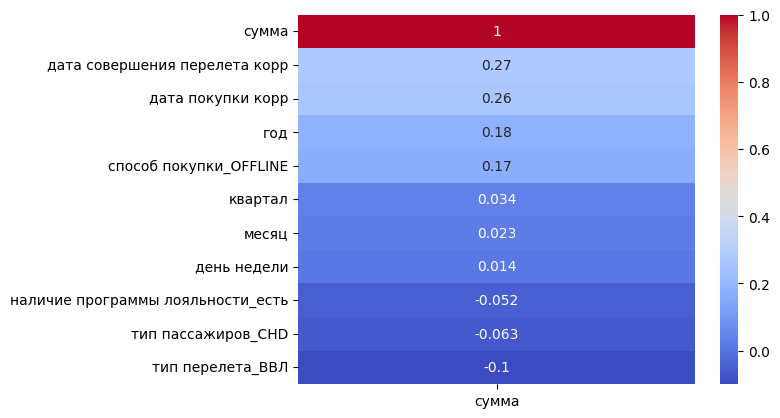

In [214]:
sns.heatmap(correlations, annot=True, cmap='coolwarm')

Видим, что связь со всеми показателями по шкале Чеддока слабая. Показатели указывают на отсутствие выраженных линейных зависимостей между выручкой и большинством признаков. Небольшие положительные корреляции с датой полёта (0.27), датой покупки (0.26), годом (0.22) и способом покупки офлайн (0.17) говорят лишь о слабых тенденциях, которые не позволяют утверждать о какой-либо устойчивой зависимости.

Когда мы сравнивали выручку с количеством покупок, мы использовали агреггированные данные по месяцам, которые устраняли шум и отражали общую динамику объёмов продаж и доходов, поэтому там были очень высокие показатели, а здесь нет.


Дополнительно построим матрицы корреляций, рассчитанных методами Спирмена и Кенделла

In [222]:
correlations = data_corr.corr(method="spearman")['сумма'].sort_values(ascending=False)
correlations = pd.DataFrame(correlations)
correlations

,сумма
сумма,1.000000
дата совершения перелета корр,0.272641
дата покупки корр,0.266133
год,0.189694
способ покупки_OFFLINE,0.157627
квартал,0.015544
день недели,0.014108
месяц,0.003757
наличие программы лояльности_есть,-0.055781
тип пассажиров_CHD,-0.057673


<Axes: >

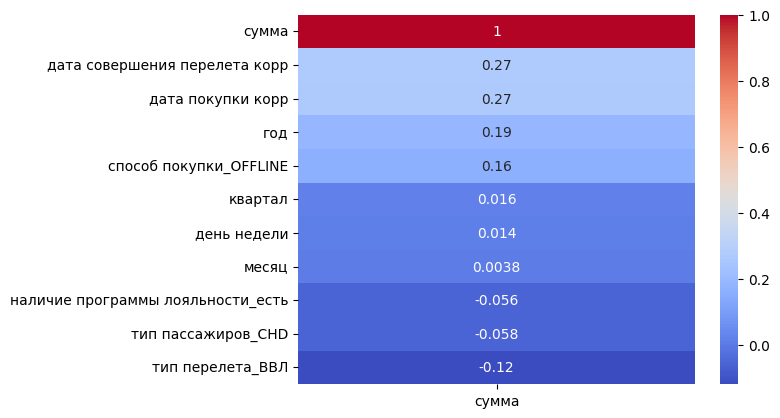

In [227]:
sns.heatmap(correlations, annot=True, cmap='coolwarm')

In [228]:
orrelations = data_corr.corr(method="kendall")['сумма'].sort_values(ascending=False)
correlations = pd.DataFrame(correlations)
correlations

,сумма
сумма,1.000000
дата совершения перелета корр,0.272641
дата покупки корр,0.266133
год,0.189694
способ покупки_OFFLINE,0.157627
квартал,0.015544
день недели,0.014108
месяц,0.003757
наличие программы лояльности_есть,-0.055781
тип пассажиров_CHD,-0.057673


Ничего не меняется